# How does the TetrisCNN decision boundary read in measurable spin correlators?

This is the working notebook behind the Fig. 5 / Fig. 6 analysis of the main text, not a
figure generator: none of the PDFs it writes are used in the manuscript build. It is kept
in the repository because it is the sole source of several numbers the text quotes, in
the appendix on fitting the decision boundary and in the Ising panel of
Fig. 6, and because it generates the LaTeX table behind the
decision-boundary appendix (see the note before the final section).

### The question

Fig. 5 shows that each surviving branch activation
$z_k$ is close to a linear function of the spin correlators of its own footprint
(the main text's "Interpretable architecture of TetrisCNN" section). Fig. 6 shows that the
classifier's decision boundary, drawn in those activations, is a low-order surface.
Neither result by itself makes the *boundary* physical: the surface in
Fig. 6(b) is still quoted in $z$-space, a coordinate system
internal to the network.

This notebook closes that gap on one representative XY run (the $C_4$-equivariant model
used for the surface panel): it fits an affine map $z_k \approx a_k C_k + b_k$ from each
active branch to its leading correlator, substitutes it into the fitted decision
polynomial, and asks how much of the classifier's accuracy survives being rewritten in
terms of *measured* correlators rather than network activations.

The substitution is not free. It is exact only where the affine fit itself is exact, and a
one-correlator readout typically reaches $R^2\approx0.97$--$0.98$, not $1$. Evaluating the
rewritten equation on measured correlators therefore loses a small amount of accuracy
relative to evaluating it on $z$, in proportion to that residual. That loss is the point of
the comparison, not a defect in it: recovering $C_k$ by inverting the observed $z_k$ would
reproduce the latent accuracy exactly and would say nothing about how good the correlator
readout is on its own.

The same pipeline runs a second time on an Ising run, where the L1 penalty has already
collapsed the bottleneck to a single branch, so the "decision surface" is one threshold on
one number and the affine map turns that number directly into a magnetization.

### What it reads

One XY run folder, `Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2` by default (or its
non-equivariant counterpart), and one Ising run folder,
`Plots_data/Ising_C4_smallkernels_lam3_seed42_p2`. Each holds `config.json`, `net1.pt` and
`net2.pt` copied out of the gitignored `logs/` tree (`Plots_data/README.md` documents the
provenance of each). Nothing here is imported from `scripts/`; the machinery is inlined
from `Figure5.ipynb` and `Figure6.ipynb`, so this notebook depends only on
`tetriscnn`, `colors.py` and `paper.mplstyle`.

### Running it

The notebook runs top to bottom on a fresh kernel. It did not always: one cell in
section 2 had been commented out while later cells still used the names it defines, and
two helper functions were defined further down than their first use, which only worked
when cells were executed out of order. Both have been corrected without changing any
computation. Re-executing it reproduces every number quoted from it in the manuscript,
and regenerates `Plots/deliverable_equations.tex` byte for byte.


In [1]:
import os

from tetriscnn import PAPER_MPLSTYLE

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import sympy as sp
import torch
from IPython.display import Math, display
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage import measure
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from torch.utils.data import DataLoader

from tetriscnn.datasets import create_datasets
from tetriscnn.interpret import (
    best_subset_terms, fit_activation_to_correlators, plateau_index,
)
from tetriscnn.models import ShapeAdaptiveConvNet, SmallModel
from tetriscnn.utils import (
    logistic_penalty_kwargs,
    AttrDict, DEVICE, branch_label, kernel_to_latex_pattern, load_json,
)

from tetriscnn.colors import COLORS, blue_cmap

# Paths below (Plots_data/ in, Plots/ out) are relative to the repository root;
# move there so the notebook runs the same from the root or from notebooks/.
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))
Path("Plots/SVG").mkdir(parents=True, exist_ok=True)

## Configuration

One run drives everything. `BASEPATH` is a **run folder**, the level holding `net1.pt`,
`net2.pt` and `config.json`, which for a `partition` experiment is the `partition_{i}`
folder, not its `seed_{n}` parent.

In [2]:
RUN_TAG = "C4"          # "C4" (equivariant) or "plain" (non-equivariant)

# The XY run this whole notebook is quoted from, copied out of the gitignored
# logs/ tree into Plots_data/ (see Plots_data/README.md). Both are the
# `partition` task at lambda_max = 3.
BASEPATH = Path({
    "C4":    "Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2",
    "plain": "Plots_data/XY_XZ_plain_smallkernels_lam3_seed46_p2",
}[RUN_TAG])

# Everything -- the BFA affine maps and every boundary -- is FITTED on `FIT_SPLIT`,
# and every accuracy is REPORTED on both splits. Fitting and plotting on train keeps the
# figure showing the data the equations were derived from; the val column is what says
# whether they generalise. A gap between the two columns is the honest measure of how
# much of an equation's accuracy is fitted noise.
FIT_SPLIT = "train"
SPLITS = ("train", "val")
SPLIT = FIT_SPLIT          # backwards-compatible alias used by `analyse_run`

# Latent coordinates. None -> the three most active surviving branches. The plain run is
# pinned because the published figure used (1x1, 1x2, diag) = [0, 2, 3], whereas ranking
# by mean |z| swaps the diagonal for the vertical domino.
BRANCH_OVERRIDE = {"C4": None, "plain": [0, 2, 3]}[RUN_TAG]
N_DIMS = 3              # the surface panel needs three coordinates by construction

# --- part 1: the correlator readout of each branch (Figure5's rule) -------------
CORR_MAX_TERMS = 5
CORR_PLATEAU_TOL = 0.05
CORR_PLATEAU_FLOOR = 0.95
CORR_SUFFICIENT = None    # absolute "good enough" R^2 bar; None -> plateau rule only

# The axis coordinate is the LEADING forward-selected correlator, i.e. the single most
# explanatory one, even when the quoted equation keeps more. Three axes need three
# scalars, and the leading term is the one the nested hierarchy calls most important.
# The R^2 cost of that truncation is printed rather than assumed.

# --- part 2: the boundary in latent space (Figure6's machinery) -----------------
DEGREES = (1, 2)          # 1 = plane, 2 = square. 3 available but not compared here.
CS = (0.01, 0.1, 1.0)

MAX_TERMS = 6
PLATEAU_TOL = 0.002       # in CV accuracy, not R^2 -- these paths are much flatter
PLATEAU_FLOOR = 0.95
SUFFICIENT_ACC = 0.99     # absolute bar; set to None to fall back to the plateau rule
CROSS_TERM_MARGIN = 0.005 # a cross term must beat the best pure one by this to be taken

# --- part 3: how the correlator-space boundary is obtained ----------------------------
# "substituted" -- push the latent equation through z_k -> a_k C_k + b_k. An exact
#                  rewrite of the SAME boundary, evaluated on measured correlators, so it
#                  pays the BFA residual.
# "direct"      -- FIT a boundary in the three correlators from scratch. A different
#                  boundary, which the affine map cannot reach: it is free to place terms
#                  where the correlators (not the activations) separate the classes.
# Both are always computed and compared; this only selects which one the manuscript
# figures draw and which one the flip panel measures against.
CORR_FIT_MODE = "direct"

# --- part 4: what counts as an acceptable rewrite -------------------------------------
# See the "verdict" cell in section 4; edit `rewrite_verdict` there, not a constant here.
ACCEPTABLE_DROP = 0.01    # accuracy the correlator rewrite may lose before it is flagged

# Cross-term penalty for the DIRECT correlator fit, set separately from the latent one.
# A candidate's CV accuracy is reduced by
#             + DEGREE_MARGIN_DIRECT     * (total_degree     - 1)
# before the forward search takes its argmax, so a term must EARN its complexity. With
# the degree margin at 0 and only bilinear cross terms present this is exactly the old
# "beat the best pure term by CROSS_TERM_MARGIN" rule, which is why the defaults below
# reproduce the numbers already quoted.
#
# Raise CROSS_TERM_MARGIN_DIRECT to discourage C_i C_j terms; raise DEGREE_MARGIN_DIRECT
# to additionally discourage high powers (it charges X^2 as well as X Y, which the cross
# margin alone does not). FORBID_CROSS_DIRECT removes them from the candidate pool
# entirely -- the path then simply runs out of pure terms, which is a legitimate answer.
# Set to 0.02 rather than the latent fit's 0.005 on the evidence of the comparison
# cell in section 3b: on this run the cross terms the direct search picks up are fitting
# noise -- forbidding them RAISES held-out accuracy (0.9823 -> 0.9830) while making the
# equation a sum of powers. 0.02 is enough to exclude them here; it is a soft margin, so
# an interaction that genuinely carries the boundary can still win.
CROSS_TERM_MARGIN_DIRECT = 0.02
DEGREE_MARGIN_DIRECT = 0.0
FORBID_CROSS_DIRECT = False

SEED = 0
ELEV, AZIM = 25, -65
MAX_PTS = 3000
OUTDIR = Path("Plots")
OUTDIR.mkdir(exist_ok=True)

print(f"run   : {BASEPATH}\nexists: {BASEPATH.exists()}\nsplit : {SPLIT}")

run   : Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2
exists: True
split : train


## Load the run

One loader, one forward pass. `shuffle=False` over the whole split in a single batch, so
snapshots, activations, logits and times all align index-for-index: the correlator
matrix built in section 1 relies on that alignment.

In [3]:
def load_run(run_folder: Path, split: str = "val"):
    """Config + weights from a run folder, with one split pushed through the net."""
    cf = AttrDict()
    cf.update(load_json(str(run_folder), "config.json"))

    # Legacy runs recorded kernels without a stride entry.
    for k in range(len(cf.kernels)):
        if len(cf.kernels[k]) < 5:
            cf.kernels[k].append(1)

    # Point the config at where it was LOADED from, not where it was first saved.
    cf.logdir = cf.seed_folder = str(run_folder)
    cf.return_all_data = False

    train_ds, val_ds = create_datasets(cf)
    dataset = {"train": train_ds, "val": val_ds}[split]

    net1 = ShapeAdaptiveConvNet(
        in_channels=dataset[0][0].shape[0],
        kernels=cf.kernels,
        equivariant=cf.equivariant,
        hidden_size=cf.hidden_size,
        init=cf.init,
        device=DEVICE,
    ).to(DEVICE)
    net2 = SmallModel(
        [len(cf.kernels), 32, 16, dataset.output_dim], device=DEVICE
    ).to(DEVICE)
    net1.load_state_dict(torch.load(run_folder / "net1.pt", map_location=DEVICE))
    net2.load_state_dict(torch.load(run_folder / "net2.pt", map_location=DEVICE))
    net1.eval()
    net2.eval()

    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            z = net1(x)
            out = net2(z)

    return {
        "cf": cf, "path": run_folder, "split": split,
        "x": x.cpu().numpy(), "z": z.cpu().numpy(), "out": out.cpu().numpy(),
        "times": dataset.times.cpu().numpy(),
        "group": cf.equivariant_group if getattr(cf, "equivariant", False) else None,
        "channels": ["X", "Z"] if x.shape[1] == 2 else ["Z"],
    }


def active_branches(z, abs_tol=1e-3, rel_tol=1e-3):
    """Branch indices the L1 penalty did not kill.

    A killed branch has mean|z| of order 1e-9, not exactly zero, so a float-epsilon
    threshold lets dead branches through -- and a dead branch has zero variance, which
    turns any downstream fit into garbage.
    """
    mags = np.abs(z).mean(axis=0)
    cut = max(abs_tol, rel_tol * mags.max())
    return [k for k in range(z.shape[1]) if mags[k] > cut]

`active_branches` marks a branch alive once its mean $|z_k|$ clears a small floor (a
killed branch sits at mean $|z|\sim10^{-9}$, not exactly zero, so a hard zero test would
let numerical noise through and turn a dead branch's activations into three columns of
garbage for every downstream fit). The printout below ranks the surviving branches by that
magnitude and shows which three fill `LATENT`, the coordinate system every later section
works in. `BRANCH_OVERRIDE` exists only because the published non-equivariant figure pins
a specific triple that ranking by magnitude alone would not reproduce (see the
configuration cell above).


In [4]:
RUN_SPLITS = {s: load_run(BASEPATH, s) for s in SPLITS}
D = RUN_SPLITS[FIT_SPLIT]                     # the split everything is fitted on
CF, GROUP, CHANNELS = D["cf"], D["group"], D["channels"]

mags = np.abs(D["z"]).mean(axis=0)
ranked = sorted(active_branches(D["z"]), key=lambda k: -mags[k])
LATENT = list(BRANCH_OVERRIDE) if BRANCH_OVERRIDE is not None else ranked[:N_DIMS]
if len(LATENT) < N_DIMS:
    raise ValueError(
        f"only {len(LATENT)} surviving branches ({LATENT}); the surface needs {N_DIMS}. "
        f"Pin them with BRANCH_OVERRIDE or choose a run with a wider bottleneck.")

# The NETWORK's class is the target throughout, on every split.
YS = {s: RUN_SPLITS[s]["out"].argmax(axis=1) for s in SPLITS}
ZS = {s: np.column_stack([RUN_SPLITS[s]["z"][:, b] for b in LATENT]) for s in SPLITS}
Y_NET, Z = YS[FIT_SPLIT], ZS[FIT_SPLIT]

print(f"{CF.dataset} / {CF.task}   equivariant={CF.equivariant} group={GROUP}")
print(f"{len(CF.kernels)} branches, {len(ranked)} active;  fitted on {FIT_SPLIT!r}")
for s in SPLITS:
    print(f"  {s:>5}: {len(ZS[s]):>6} snapshots, class balance {np.bincount(YS[s])}")
for k in ranked:
    mark = f"  <- latent slot {LATENT.index(k)}" if k in LATENT else ""
    print(f"  branch {k:>2}  shape={str(CF.kernels[k][0]):>6} "
          f"mask={str(CF.kernels[k][3]):>20}  mean|z|={mags[k]:.4f}{mark}")


 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples


times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])

Using C4-equivariant convolutional branches.



 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])

Using C4-equivariant convolutional branches.


Paris_XY_XZ / partition   equivariant=True group=C4
5 branches, 3 active;  fitted on 'train'
  train:  10124 snapshots, class balance [3458 6666]
    val:   4347 snapshots, class balance [1469 2878]
  branch  0  shape=[1, 1] mask=                None  mean|z|=0.5116  <- latent slot 0
  branch  1  shape=[2, 1] mask=                None  mean|z|=0.0437  <- latent slot 1
  branch  2  shape=[2, 2] mask=    [[1, 0], [0, 1]]  mean|z|=0.0357  <- latent slot 2


## 1. The BFA readout: one correlator per branch

`fit_activation_to_correlators` enumerates every sub-pattern of the branch footprint
(single-basis *and* cross-basis products) and fits all of them. That fit is exact
($R^2=1$) and unreadable, so the equation is cut by forward selection: build a nested
importance hierarchy, then keep the shortest prefix that is already as good as the path
gets, subject to a floor.

For the **axes** of section 3 only the leading term is used: three coordinates need
three scalars, and the leading term is the one the hierarchy names most important. The
table below prints the $R^2$ of the leading term alone next to the $R^2$ of the full
quoted equation, so the cost of that truncation is visible rather than assumed.

For an **equivariant** branch the fitted feature is not the ordinary correlator $C[P]$
but the orbit average $\overline{C}^{\,G}[P] = \frac{1}{|G|}\sum_g C_{g\cdot F}[g\cdot P]$,
whose members need not even share a footprint shape. The glyphs drawn are canonical
representatives; the symbol is what says the quantity is orbit-averaged.

In [5]:
FITS, PROBE = {}, {}
for k in LATENT:
    probe = fit_activation_to_correlators(
        D["x"], D["z"][:, k], CF.kernels[k], channel_names=CHANNELS,
        group=GROUP, verbose=False)
    PROBE[k] = probe
    # A branch cannot be given a bigger budget than it has terms (the 1x1 branch only
    # offers 3), so clamp rather than raise.
    FITS[k] = fit_activation_to_correlators(
        D["x"], D["z"][:, k], CF.kernels[k], channel_names=CHANNELS, group=GROUP,
        select_terms=min(CORR_MAX_TERMS, len(probe["patterns"])),
        select_strategy="forward", plateau_tol=CORR_PLATEAU_TOL,
        plateau_floor=CORR_PLATEAU_FLOOR, plateau_sufficient=CORR_SUFFICIENT,
        verbose=False)

hdr = (f"{'branch':>6} {'kernel':>8} {'terms':>6} {'kept':>5} {'R2_full':>8} "
       f"{'R2_kept':>8} {'R2_lead':>8}  forward path R^2 by size")
print(hdr); print("-" * len(hdr))
for k in LATENT:
    r = FITS[k]
    trail = "  ".join(f"{v:.4f}" for _, v in r["selection_path"])
    lead_r2 = r["selection_path"][0][1]
    flag = "" if r["selected_r_squared"] >= CORR_PLATEAU_FLOOR else "  <- BELOW FLOOR"
    print(f"{k:>6} {str(CF.kernels[k][0]):>8} {len(r['patterns']):>6} "
          f"{len(r['selected_terms']):>5} {r['r_squared']:>8.4f} "
          f"{r['selected_r_squared']:>8.4f} {lead_r2:>8.4f}  {trail}{flag}")

branch   kernel  terms  kept  R2_full  R2_kept  R2_lead  forward path R^2 by size
---------------------------------------------------------------------------------
     0   [1, 1]      3     1   1.0000   0.9983   0.9983  0.9983  0.9997  1.0000
     1   [2, 1]     15     1   1.0000   0.9662   0.9662  0.9662  0.9853  0.9930  0.9977  0.9986
     2   [2, 2]     15     1   1.0000   0.9773   0.9773  0.9773  0.9871  0.9922  0.9950  0.9972


In [6]:
# The audit trail behind each readout: correlators in the order the greedy search found
# them, the running R^2, and -- in the last column -- exhaustive best-subset at the SAME
# size. Greedy is not optimal at every k (a term can look weak alone and be strong in
# company), so this says what the nesting costs. `<<` marks the plateau cut, `**` the
# leading term used as an axis in section 3.
def _r2_of(res, cols):
    X_ = res["correlators_with_const"]
    return sm.OLS(res["outputs"], X_[:, [0] + list(cols)]).fit().rsquared


for k in LATENT:
    res = FITS[k]
    n_keep = len(res["selected_terms"])
    print(f"branch {k}  kernel {CF.kernels[k][0]}  "
          f"({len(res['patterns'])} terms available)")
    print(f"   {'step':>4} {'R2':>8} {'gain':>9} {'R2_bestsub':>11}  term")
    prev = 0.0
    for i, (col, r2) in enumerate(res["selection_path"], 1):
        best_at_i = _r2_of(res, best_subset_terms(res["correlators_with_const"],
                                                  res["outputs"], i)[0])
        mark = ("**" if i == 1 else "  ") + ("<<" if i == n_keep else "  ")
        print(f"{mark} {i:>4} {r2:>8.4f} {r2 - prev:>+9.4f} {best_at_i:>11.4f}"
              f"  {res['patterns'][col - 1]}")
        prev = r2
    print()

branch 0  kernel [1, 1]  (3 terms available)
   step       R2      gain  R2_bestsub  term
**<<    1   0.9983   +0.9983      0.9983  $\substack{X:\blacksquare \\ Z:\square}$
        2   0.9997   +0.0014      0.9997  $\substack{X:\square \\ Z:\blacksquare}$
        3   1.0000   +0.0003      1.0000  $\substack{X:\blacksquare \\ Z:\blacksquare}$

branch 1  kernel [2, 1]  (15 terms available)
   step       R2      gain  R2_bestsub  term
**<<    1   0.9662   +0.9662      0.9662  $\substack{X:\square\square \\ Z:\blacksquare\blacksquare}$
        2   0.9853   +0.0191      0.9853  $\substack{X:\square\blacksquare \\ Z:\blacksquare\square}$


        3   0.9930   +0.0077      0.9930  $\substack{X:\blacksquare\square \\ Z:\square\square}$


        4   0.9977   +0.0046      0.9977  $\substack{X:\blacksquare\blacksquare \\ Z:\square\square}$


        5   0.9986   +0.0010      0.9986  $\substack{X:\blacksquare\square \\ Z:\blacksquare\blacksquare}$

branch 2  kernel [2, 2]  (15 terms available)
   step       R2      gain  R2_bestsub  term
**<<    1   0.9773   +0.9773      0.9773  $\substack{X:\substack{\square\square \\ \square\square} \\ Z:\substack{\blacksquare\square \\ \square\blacksquare}}$
        2   0.9871   +0.0099      0.9871  $\substack{X:\substack{\blacksquare\square \\ \square\square} \\ Z:\substack{\square\square \\ \square\blacksquare}}$


        3   0.9922   +0.0051      0.9922  $\substack{X:\substack{\square\square \\ \square\square} \\ Z:\substack{\square\square \\ \square\blacksquare}}$


        4   0.9950   +0.0028      0.9950  $\substack{X:\substack{\square\square \\ \square\blacksquare} \\ Z:\substack{\square\square \\ \square\square}}$


        5   0.9972   +0.0022      0.9972  $\substack{X:\substack{\blacksquare\square \\ \square\square} \\ Z:\substack{\blacksquare\square \\ \square\square}}$



### The three affine maps

Each axis coordinate comes from an **unpenalized one-term refit**
$z_k \approx a_k\,C_k + b_k$ on the leading correlator alone, not from the coefficient
that correlator carries inside the longer quoted equation. Those two numbers differ, and
the one-term refit is the right one here: it is the coefficient of the map actually being
substituted in section 3, whereas the multi-term coefficient is conditioned on partners
that the substitution drops.

`correlators_with_const` is the design matrix the fit was built on, so its leading column
*is* the measured (orbit-averaged) correlator per snapshot: the correlator matrix `C` is
read straight off it rather than recomputed.

In [7]:
def correlator_symbol(group):
    """Symbol in front of each pattern glyph.

    For an equivariant branch this must not be a bare C: the branch is linear in the
    orbit average, and for a non-square footprint the orbit members do not even share a
    shape (the C4 orbit of a 2x1 domino alternates 2x1 / 1x2). The glyph drawn is the
    canonical representative, so a bare C[P] would read as a single 2x1 correlator.
    """
    if group is None:
        return "C"
    return r"C_{\mathrm{rot}}"


CORR_SYM = correlator_symbol(GROUP)
VAR_NAMES = ["X", "Y", "Z"][:len(LATENT)]
SYMS = sp.symbols(" ".join(VAR_NAMES), real=True)
SYMS = (SYMS,) if isinstance(SYMS, sp.Symbol) else tuple(SYMS)

AXES = []       # one record per latent slot
for slot, k in enumerate(LATENT):
    res = FITS[k]                      # fitted on FIT_SPLIT, like everything else
    lead_col = res["selection_path"][0][0]
    c_vals = res["correlators_with_const"][:, lead_col]
    ols1 = sm.OLS(res["outputs"], sm.add_constant(c_vals)).fit()
    AXES.append({
        "slot": slot, "branch": k, "col": lead_col,
        "pattern": res["patterns"][lead_col - 1],
        "a": float(ols1.params[1]), "b": float(ols1.params[0]),
        "r2": float(ols1.rsquared), "var": VAR_NAMES[slot],
    })


def correlator_matrix(d):
    """The measured leading correlators of every latent branch, for one split.

    The design matrix is rebuilt from that split's snapshots and the SAME column index is
    read out. Column order is a deterministic function of the branch spec and channel
    names, so the indices transfer -- but that is asserted rather than assumed, because a
    silent mismatch here would swap one correlator for another and still produce
    plausible-looking numbers.
    """
    M = np.empty((len(d["z"]), len(LATENT)))
    for slot, k in enumerate(LATENT):
        r = fit_activation_to_correlators(
            d["x"], d["z"][:, k], CF.kernels[k], channel_names=CHANNELS,
            group=GROUP, verbose=False)
        assert r["patterns"] == FITS[k]["patterns"], (
            f"branch {k}: correlator column order differs between splits")
        M[:, slot] = r["correlators_with_const"][:, AXES[slot]["col"]]
    return M


CMATS = {s: correlator_matrix(RUN_SPLITS[s]) for s in SPLITS}
C = CMATS[FIT_SPLIT]


def acc_all(expr, space):
    """In-sample and held-out accuracy of one boundary, as a dict keyed by split."""
    src = ZS if space == "latent" else CMATS
    return {s: accuracy_of(expr, src[s], YS[s]) for s in SPLITS}


def show_axis_maps(title="activation -> correlator maps (fitted on "
                         f"{FIT_SPLIT!r})"):
    """Print the three affine readouts.

    Called from several places on purpose: these three numbers are what every correlator
    equation in this notebook is built on, and scrolling back to section 1 to check which
    correlator `X` means is exactly the friction that makes an equation get misread.
    """
    print(title)
    for ax_ in AXES:
        print(f"  {ax_['var']} = {CORR_SYM}[branch {ax_['branch']} lead]   "
              f"z = {ax_['a']:+.4f} * {ax_['var']} {ax_['b']:+.4f}   "
              f"R^2={ax_['r2']:.4f}")
        display(Math(
            rf"{ax_['var']} \;=\; {CORR_SYM}\left[{ax_['pattern'].strip('$')}\right]"
            rf"\quad\Longleftarrow\quad "
            rf"z\left[{branch_label(CF, ax_['branch'], full_latex=True).strip('$')}"
            rf"\right] \approx {ax_['a']:.3f}\,{ax_['var']} "
            rf"{'-' if ax_['b'] < 0 else '+'} {abs(ax_['b']):.3f}"
            rf"\quad (R^2 = {ax_['r2']:.3f})"))


print(f"group={GROUP}   correlator symbol={CORR_SYM!r}   fitted on {FIT_SPLIT!r}\n")
show_axis_maps()
for s in SPLITS:
    rng = ", ".join(f"[{CMATS[s][:, a['slot']].min():+.3f}, "
                    f"{CMATS[s][:, a['slot']].max():+.3f}]" for a in AXES)
    print(f"  {s:>5} correlator ranges: {rng}")

# How well the three maps together reproduce the latent coordinates. This is the budget
# the correlator rewrite has to spend: whatever accuracy is lost in section 4 is lost
# here first, in these residuals.
ZHATS = {s: np.column_stack([a["a"] * CMATS[s][:, a["slot"]] + a["b"] for a in AXES])
         for s in SPLITS}
Z_HAT = ZHATS[FIT_SPLIT]
print("\nreconstruction z_hat = a*C + b:")
for s in SPLITS:
    for ax_ in AXES:
        j = ax_["slot"]
        resid = ZS[s][:, j] - ZHATS[s][:, j]
        rms = float(np.sqrt((resid ** 2).mean()))
        print(f"  {s:>5} slot {j}: RMS residual {rms:.5f}  "
              f"({100 * rms / ZS[s][:, j].std():.2f}% of the sd of z)")

group=C4   correlator symbol='C_{\\mathrm{rot}}'   fitted on 'train'

activation -> correlator maps (fitted on 'train')
  X = C_{\mathrm{rot}}[branch 0 lead]   z = -1.5594 * X +0.0185   R^2=0.9983


<IPython.core.display.Math object>

  Y = C_{\mathrm{rot}}[branch 1 lead]   z = -0.2144 * Y -0.0302   R^2=0.9662


<IPython.core.display.Math object>

  Z = C_{\mathrm{rot}}[branch 2 lead]   z = +0.1574 * Z -0.0140   R^2=0.9773


<IPython.core.display.Math object>

  train correlator ranges: [-1.000, +1.000], [-1.000, +1.000], [-0.567, +1.000]
    val correlator ranges: [-0.905, +1.000], [-1.000, +0.379], [-0.433, +1.000]

reconstruction z_hat = a*C + b:
  train slot 0: RMS residual 0.02535  (4.09% of the sd of z)
  train slot 1: RMS residual 0.01019  (18.38% of the sd of z)
  train slot 2: RMS residual 0.00686  (15.08% of the sd of z)
    val slot 0: RMS residual 0.02485  (3.99% of the sd of z)
    val slot 1: RMS residual 0.01018  (18.24% of the sd of z)
    val slot 2: RMS residual 0.00672  (14.72% of the sd of z)


## 2. The boundary in latent space: plane vs square

Machinery inlined from `Figure6.ipynb`:

- `fit_surface`: a polynomial logistic boundary of a given degree with an $L_1$ penalty,
  reported with in-sample **and** cross-validated accuracy. Only the latter is comparable
  across degrees, since a higher degree always improves the in-sample fit.
- `boundary_expr` / `subset_expr`: rebuild the fitted decision polynomial $F=0$ as an
  exact SymPy expression in the **original, unscaled** coordinates, undoing the
  `StandardScaler`. This is what makes the equation quotable, the isosurface exact, and
  the substitution of section 3 possible at all.
- `marching_surface`: the $F=0$ isosurface by marching cubes on the polynomial itself.
- `parsimonious`: the one-standard-error rule: the sparsest fit within one CV standard
  deviation of the best.

The target `y` is the **network's** predicted class, `out.argmax(1)`. These surfaces
describe the classifier, so a point on the wrong side is a snapshot the closed form fails
to describe, not one the physics got wrong.

In [8]:
import re

_TOKEN = re.compile(r"^([A-Z])(?:\^(\d+))?$")


def boundary_expr(scaler, clf, feat_names, var_names) -> sp.Expr:
    """The exact decision polynomial F(...) in ORIGINAL (unscaled) coordinates."""
    syms = sp.symbols(" ".join(var_names), real=True)
    syms = (syms,) if isinstance(syms, sp.Symbol) else tuple(syms)
    scaled = {name: (s - float(m)) / float(sd)
              for name, s, m, sd in zip(var_names, syms, scaler.mean_, scaler.scale_)}
    expr = sp.Float(float(clf.intercept_[0]))
    for fname, coef in zip(feat_names, clf.coef_[0]):
        if abs(coef) < 1e-12:
            continue
        term = sp.Float(float(coef))
        for tok in fname.split():
            var, power = _TOKEN.match(tok).groups()
            term *= scaled[var] ** (int(power) if power else 1)
        expr += term
    return expr


def fit_surface(X, y, degree=2, C_=0.04, penalty="l1", n_splits=5, seed=SEED,
                var_names=None):
    """Polynomial logistic boundary; in-sample and cross-validated accuracy."""
    var_names = var_names or VAR_NAMES[:X.shape[1]]
    pipe = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=degree, include_bias=False),
        LogisticRegression(**logistic_penalty_kwargs(penalty == "l1"), C=C_,
                           solver="liblinear" if penalty == "l1" else "lbfgs",
                           max_iter=20000, class_weight="balanced", random_state=seed),
    )
    pipe.fit(X, y)
    feat_names = pipe.named_steps["polynomialfeatures"].get_feature_names_out(var_names)
    coefs = pipe.named_steps["logisticregression"].coef_[0]
    nonzero = [(n, float(c)) for n, c in zip(feat_names, coefs) if abs(c) > 1e-8]
    cv = cross_val_score(pipe, X, y, scoring="accuracy", n_jobs=-1,
                         cv=StratifiedKFold(n_splits, shuffle=True, random_state=seed))
    return {
        "pipe": pipe, "degree": degree, "C": C_, "penalty": penalty,
        "acc": float(pipe.score(X, y)), "cv_mean": float(cv.mean()),
        "cv_std": float(cv.std()), "n_terms": len(nonzero), "n_feats": len(feat_names),
        "terms": nonzero, "feat_names": list(feat_names), "var_names": var_names,
        "expr": boundary_expr(pipe.named_steps["standardscaler"],
                              pipe.named_steps["logisticregression"],
                              feat_names, var_names),
    }


def marching_surface(expr, X, n=(220, 90, 90), pad=(0.15, 0.15, 0.25)):
    """Isosurface F=0 of the exact polynomial, in original coordinates."""
    syms = sp.symbols("X Y Z", real=True)
    rngs = []
    for d, (npts, p) in enumerate(zip(n, pad)):
        lo, hi = X[:, d].min(), X[:, d].max()
        m = p * (hi - lo)
        rngs.append(np.linspace(lo - m, hi + m, npts))
    grid = np.meshgrid(*rngs, indexing="ij")
    F = sp.lambdify(syms, sp.expand(expr), "numpy")(*grid)
    F = np.broadcast_to(np.asarray(F, dtype=float), grid[0].shape)
    if F.min() > 0 or F.max() < 0:
        return None, None
    verts, faces, _, _ = measure.marching_cubes(
        F, level=0, spacing=tuple(r[1] - r[0] for r in rngs))
    return verts + np.array([r[0] for r in rngs]), faces


def parsimonious(rows, key="cv_mean"):
    """One-SE rule: sparsest fit within one CV standard deviation of the best."""
    best = max(rows, key=lambda r: r[key])
    ok = [r for r in rows if r[key] >= best[key] - best["cv_std"]]
    return min(ok, key=lambda r: (r["n_terms"], r["degree"], -r[key]))


def print_table(rows, top=None):
    hdr = f"{'deg':>4}{'C':>8}{'acc':>9}{'cv_acc':>9}{'+-':>7}{'terms':>8}  formula-terms"
    print(hdr); print("-" * len(hdr))
    for r in (rows if top is None else rows[:top]):
        names = ",".join(n for n, _ in r["terms"])
        print(f"{r['degree']:>4}{r['C']:>8.3g}{r['acc']:>9.4f}{r['cv_mean']:>9.4f}"
              f"{r['cv_std']:>7.4f}{r['n_terms']:>5}/{r['n_feats']:<3}  {names[:60]}")


def round_expr(expr, num_digits=3):
    """Round every float in a SymPy expression.

    Numbers below the rounding scale are kept in exponential form rather than flushed to
    zero, so a genuinely tiny term still shows up as tiny instead of vanishing.
    """
    rounded = {}
    for atom in expr.atoms(sp.Number):
        if abs(atom) > 1 / 10 ** num_digits:
            rounded[atom] = round(atom, num_digits)
        else:
            rounded[atom] = float(f"{float(atom):+.{num_digits}e}")
    return expr.xreplace(rounded)


def eval_boundary(expr, X, var_names=None):
    """Predicted class of a SymPy boundary, F > 0 -> class 1 (as `pipe.predict`)."""
    var_names = var_names or VAR_NAMES
    syms = sp.symbols(" ".join(var_names), real=True)
    syms = (syms,) if isinstance(syms, sp.Symbol) else tuple(syms)
    f = sp.lambdify(syms, sp.expand(expr), "numpy")
    vals = np.broadcast_to(np.asarray(f(*X.T), dtype=float), (len(X),))
    return (vals > 0).astype(int)


def accuracy_of(expr, X, y, var_names=None):
    return float((eval_boundary(expr, X, var_names) == y).mean())

### Is curvature worth it? The per-degree sweep

The cell below fits the decision boundary at every combination of polynomial degree and
L1 strength, and reduces the result to two choices per degree: `BEST_BY_DEGREE`, the fit
with the highest cross-validated accuracy, and `ONESE_BY_DEGREE`, the sparsest fit whose
accuracy lies within one standard error of that best (the usual one-standard-error rule
for choosing a regularization strength). Later sections build their plane and square
boundaries from these.

The penalty grid deliberately reaches weak penalties. Whether curvature is needed is
decided by comparing the best fit at each degree, and if the grid stopped while the plane
was still being regularized, the comparison would measure penalty strength rather than
geometry.

The closing line states the verdict in those terms: the square is only preferred when it
beats the plane by more than the plane's own fold-to-fold scatter, since a smaller gain
cannot be told apart from noise. The seed-averaged sweep in the next two cells asks the
same question across five seeds.


In [9]:
# The penalty grid must reach WEAK penalties (10, 100), not stop at 1.0. Whether
# curvature is needed is decided by comparing the BEST fit at each degree, and if the
# grid tops out while the plane is still being regularized, the comparison measures
# penalty strength rather than geometry.
SWEEP = [fit_surface(Z, Y_NET, degree=deg, C_=c) for deg in DEGREES for c in CS]
SWEEP.sort(key=lambda r: (-r["cv_mean"], r["n_terms"]))
print_table(SWEEP, top=8)

BEST_BY_DEGREE, ONESE_BY_DEGREE = {}, {}
for deg in DEGREES:
    rows = [r for r in SWEEP if r["degree"] == deg]
    BEST_BY_DEGREE[deg] = max(rows, key=lambda r: r["cv_mean"])
    ONESE_BY_DEGREE[deg] = parsimonious(rows)

print(f"\n{'degree':>8}{'best cv':>10}{'+-':>8}{'C':>8}   |{'1-SE cv':>9}"
      f"{'terms':>7}{'C':>8}")
print("-" * 60)
for deg in DEGREES:
    b, s = BEST_BY_DEGREE[deg], ONESE_BY_DEGREE[deg]
    print(f"{deg:>8}{b['cv_mean']:>10.4f}{b['cv_std']:>8.4f}{b['C']:>8.3g}   |"
          f"{s['cv_mean']:>9.4f}{s['n_terms']:>7}{s['C']:>8.3g}")

# Is the curvature worth it? "Worth it" = the best square clears the best plane by more
# than the plane's own fold-to-fold scatter. Anything smaller cannot be told from noise,
# and the plane is then the honest thing to quote.
plane, square = BEST_BY_DEGREE[1], BEST_BY_DEGREE[2]
d_cv = square["cv_mean"] - plane["cv_mean"]
print(f"\nbest plane cv={plane['cv_mean']:.4f} (sd {plane['cv_std']:.4f}), "
      f"best square cv={square['cv_mean']:.4f}; gain {d_cv:+.4f} -> "
      + ("curvature justified" if d_cv > plane["cv_std"]
         else "within noise -- a plane describes it just as well"))


 deg       C      acc   cv_acc     +-   terms  formula-terms
------------------------------------------------------------
   2       1   0.9985   0.9982 0.0002    5/9    X,Y,Z,X^2,X Z
   2     0.1   0.9974   0.9973 0.0007    4/9    X,Y,Z,X^2
   2    0.01   0.9908   0.9897 0.0006    4/9    X,Y,Z,X^2
   1       1   0.9819   0.9818 0.0018    3/3    X,Y,Z
   1     0.1   0.9810   0.9809 0.0017    3/3    X,Y,Z
   1    0.01   0.9793   0.9779 0.0017    3/3    X,Y,Z

  degree   best cv      +-       C   |  1-SE cv  terms       C
------------------------------------------------------------
       1    0.9818  0.0018       1   |   0.9818      3       1
       2    0.9982  0.0002       1   |   0.9982      5       1

best plane cv=0.9818 (sd 0.0018), best square cv=0.9982; gain +0.0164 -> curvature justified


The sweep that follows is a diagnostic aside, not a load-bearing computation: it refits the
quadratic boundary at fifteen values of the inverse regularization strength $C$, five seeds
each, and plots how the magnitude of every polynomial coefficient moves as the $L_1$
penalty relaxes, alongside the mean cross-validated accuracy. It is the same kind of
regularization-path evidence as the regularization-path figure in
that appendix, run here as a check on this notebook's own fit rather
than reused from it. Its output is displayed, not saved to `Plots/`, and nothing later
in the notebook reads back `SWEEP`, `SWEEP_MEAN` or `PATH_MEAN`.


In [10]:
cs_tmp = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1.0, 5, 10.0, 50, 100.0, 500, np.inf]
deg = 2
SWEEP_SEEDS = range(5)
SWEEP = []
PATH_ROWS = []

total = len(cs_tmp) * len(SWEEP_SEEDS)

for i, c in enumerate(cs_tmp):
    for seed in SWEEP_SEEDS:
        progress = i * len(SWEEP_SEEDS) + seed + 1
        print(f"[{progress}/{total}] fitting C={c:g}, seed={seed}", flush=True)

        fit_c = 1e12 if np.isinf(c) else c
        result = fit_surface(Z, Y_NET, degree=deg, C_=fit_c, seed=seed)
        result["C_requested"] = c
        result["sweep_seed"] = seed
        SWEEP.append(result)

        poly = result["pipe"].named_steps["polynomialfeatures"]
        clf = result["pipe"].named_steps["logisticregression"]
        terms = poly.get_feature_names_out(VAR_NAMES)

        for term, coefficient in zip(terms, clf.coef_[0]):
            PATH_ROWS.append({
                "C": c,
                "seed": seed,
                "term": term,
                "magnitude": abs(float(coefficient)),
            })

print(f"Completed {len(SWEEP)} fits.")

# Mean and standard deviation across seeds for each C.
SWEEP_MEAN = (
    pd.DataFrame(SWEEP)
    .groupby("C_requested")
    .agg(
        cv_mean=("cv_mean", "mean"),
        cv_std_across_seeds=("cv_mean", "std"),
        acc_mean=("acc", "mean"),
        n_terms_mean=("n_terms", "mean"),
    )
    .reset_index()
)

PATH_MEAN = (
    pd.DataFrame(PATH_ROWS)
    .groupby(["C", "term"])
    .agg(
        magnitude=("magnitude", "mean"),
        magnitude_std=("magnitude", "std"),
    )
    .reset_index()
)

# Plot the mean coefficient magnitude for every degree-2 polynomial term.
terms = list(
    PolynomialFeatures(degree=deg, include_bias=False)
    .fit(Z)
    .get_feature_names_out(VAR_NAMES)
)

finite_cs = [c for c in cs_tmp if np.isfinite(c)]
inf_x = max(finite_cs) * 3
x_positions = {
    c: (inf_x if np.isinf(c) else c)
    for c in cs_tmp
}

[1/75] fitting C=0.0001, seed=0


[2/75] fitting C=0.0001, seed=1


[3/75] fitting C=0.0001, seed=2


[4/75] fitting C=0.0001, seed=3


[5/75] fitting C=0.0001, seed=4


...

[72/75] fitting C=inf, seed=1


[73/75] fitting C=inf, seed=2


[74/75] fitting C=inf, seed=3


[75/75] fitting C=inf, seed=4


Completed 75 fits.


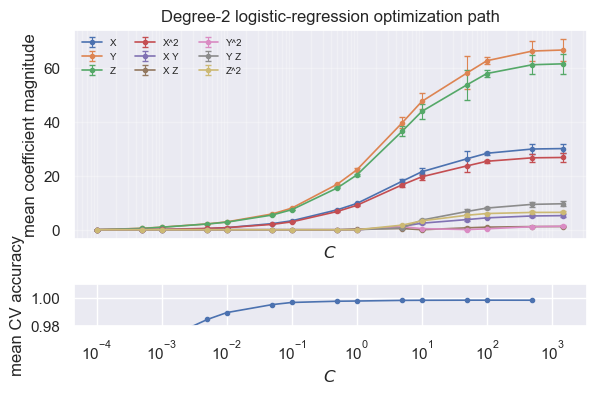

In [11]:
with plt.rc_context({"text.usetex": False}):
    fig, axs = plt.subplots(2, 1, figsize=(6.0, 3.8), sharex=True, gridspec_kw={"height_ratios": [5, 1]})

    ax = axs[0]

    for term in terms:
        path = PATH_MEAN[PATH_MEAN["term"] == term].copy()
        path["x"] = path["C"].map(x_positions)
        path = path.sort_values("x")

        ax.errorbar(
            path["x"],
            path["magnitude"],
            yerr=path["magnitude_std"],
            marker="o",
            linewidth=1.2,
            markersize=3,
            capsize=2,
            elinewidth=0.8,
            label=term,
        )

    ax.set_xscale("log")
    ax.set_xlabel(r"$C$")
    ax.set_ylabel("mean coefficient magnitude")
    ax.set_title(f"Degree-{deg} logistic-regression optimization path")
    ax.set_xticks(list(x_positions.values()))
    ax.set_xticklabels(
        [f"{c:g}" if np.isfinite(c) else r"$\infty$" for c in cs_tmp]
    )
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(ncol=3, fontsize=7, frameon=False)
    fig.tight_layout()

    ax = axs[1]

    ax.plot(
        SWEEP_MEAN["C_requested"],
        SWEEP_MEAN["cv_mean"],
        marker="o",
        linewidth=1.2,
        markersize=3,
        label="mean CV accuracy",
    )
    ax.fill_between(
        SWEEP_MEAN["C_requested"],
        SWEEP_MEAN["cv_mean"] - SWEEP_MEAN["cv_std_across_seeds"],
        SWEEP_MEAN["cv_mean"] + SWEEP_MEAN["cv_std_across_seeds"],
        alpha=0.3,
        label="±1 std",
    )

    ax.set_xscale("log")
    ax.set_xlabel(r"$C$")
    ax.set_ylabel("mean CV accuracy")
    ax.set_ylim(0.98, 1.01)

    SWEEP_MEAN

### The quotable equation at each degree

The 1-SE rule picks a *fit*, not an equation short enough to print: the LASSO leaves
whatever terms survive its penalty, in no order of importance, and how many there are is
a side effect of $C$.

So term choice is forward selection, as in both source notebooks (the most predictive
term, then the best addition given that one) cut by `plateau_index`, with `SUFFICIENT_ACC`
as an absolute override. Among candidates of near-equal merit a **pure** term ($X$, $Z^2$)
is preferred over a **cross** term ($XY$, $X^2Z$): a bilinear equation is harder to read
and harder to give a physical account of. That preference is a soft margin, not a ban, and
the printout records when a cross term won anyway.

Crucially the score is **cross-validated** accuracy. Adding a polynomial term always
improves in-sample accuracy, so an in-sample path would never plateau.

In [12]:
def poly_features(X, degree, var_names):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    return poly.fit_transform(X), list(poly.get_feature_names_out(var_names))


def _subset_pipe(Xp, y, cols, C_=1e4, seed=SEED):
    """Unpenalized logistic fit on a chosen set of polynomial features.

    C is large rather than infinite: the SUPPORT is the regularizer here, so the
    coefficients quoted for it should not additionally be shrunk.
    """
    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=C_, solver="lbfgs", max_iter=20000,
                           class_weight="balanced", random_state=seed))
    pipe.fit(Xp[:, cols], y)
    return pipe


def cv_accuracy(Xp, y, cols, C_=1e4, n_splits=5, seed=SEED):
    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=C_, solver="lbfgs", max_iter=20000,
                           class_weight="balanced", random_state=seed))
    cv = cross_val_score(pipe, Xp[:, cols], y, scoring="accuracy", n_jobs=-1,
                         cv=StratifiedKFold(n_splits, shuffle=True, random_state=seed))
    return float(cv.mean())


def is_pure(name):
    """One coordinate? `PolynomialFeatures` names are space-separated tokens, so "X" and
    "Z^2" are one token (pure) while "X Y" and "X^2 Z" are two (cross)."""
    return len(name.split()) == 1


def term_complexity(name):
    """(number of distinct variables, total degree) of a `PolynomialFeatures` term."""
    toks = name.split()
    deg = 0
    for tok in toks:
        _, p = _TOKEN.match(tok).groups()
        deg += int(p) if p else 1
    return len(toks), deg


def term_penalty(name, cross_margin=0.0, degree_margin=0.0):
    """Accuracy a candidate forfeits for being complicated.

        penalty = cross_margin * (n_vars - 1) + degree_margin * (total_degree - 1)

    A pure linear term pays nothing. `X^2` pays only the degree margin, `X Y` pays one
    cross margin plus one degree margin, `X^2 Y` pays one cross plus two degree. This
    generalises the old flat rule without changing it: with `degree_margin = 0` and only
    bilinear cross terms in play, taking the argmax of (score - penalty) is identical to
    "prefer the best pure term unless a cross term beats it by more than cross_margin".
    """
    n_vars, deg = term_complexity(name)
    return cross_margin * (n_vars - 1) + degree_margin * (deg - 1)


def forward_boundary_path(Xp, y, max_terms, names, cross_margin=0.0,
                          degree_margin=0.0, forbid_cross=False):
    """Greedy forward selection over polynomial features, scored by CV accuracy.

    Candidates are ranked by CV accuracy MINUS `term_penalty`, so complexity is charged
    against the thing being maximised rather than handled by a special case. The raw
    score is what gets recorded and printed, since that is the honest accuracy of the
    resulting equation; the penalty only decides the order terms are taken in.
    """
    chosen, remaining, steps = [], list(range(Xp.shape[1])), []
    for _ in range(min(max_terms, Xp.shape[1])):
        cand = [j for j in remaining if is_pure(names[j])] if forbid_cross else remaining
        if not cand:
            break                      # ran out of pure terms; a shorter path is the answer
        scored = {j: cv_accuracy(Xp, y, chosen + [j]) for j in cand}
        adjusted = {j: scored[j] - term_penalty(names[j], cross_margin, degree_margin)
                    for j in cand}
        pick = max(adjusted, key=lambda j: adjusted[j])

        pure = [j for j in cand if is_pure(names[j])]
        cross = [j for j in cand if not is_pure(names[j])]
        chosen.append(pick)
        remaining.remove(pick)
        steps.append({
            "col": pick, "score": scored[pick], "adjusted": adjusted[pick],
            "cross": not is_pure(names[pick]),
            "penalty": term_penalty(names[pick], cross_margin, degree_margin),
            "best_pure": max((scored[j] for j in pure), default=None),
            "best_cross": max((scored[j] for j in cross), default=None)})
    return steps


class SubsetBoundary:
    """A forward-selected fit wearing the swept fits' interface.

    `fit_surface` returns a pipeline consuming RAW coordinates, while the forward search
    works on the expanded polynomial design matrix. Wrapping the expansion here gives the
    plotting and misclassification code one calling convention instead of two.
    """

    def __init__(self, pipe, degree, cols):
        self.pipe, self.degree, self.cols = pipe, degree, cols

    def _expand(self, X):
        poly = PolynomialFeatures(degree=self.degree, include_bias=False)
        return poly.fit_transform(X)[:, self.cols]

    def decision_function(self, X):
        return self.pipe.decision_function(self._expand(X))

    def predict(self, X):
        return self.pipe.predict(self._expand(X))


def subset_expr(pipe, names, var_names):
    """Decision polynomial of a subset fit, in original (unscaled) coordinates.

    The scaler standardizes the POLYNOMIAL features, not the raw coordinates, so each
    monomial is un-standardized as a whole rather than variable by variable.
    """
    scaler = pipe.named_steps["standardscaler"]
    clf = pipe.named_steps["logisticregression"]
    syms = {v: sp.Symbol(v, real=True) for v in var_names}
    expr = sp.Float(float(clf.intercept_[0]))
    for name, coef, mu, sd in zip(names, clf.coef_[0], scaler.mean_, scaler.scale_):
        mono = sp.Integer(1)
        for tok in name.split():
            v, p = _TOKEN.match(tok).groups()
            mono *= syms[v] ** (int(p) if p else 1)
        expr += float(coef) * (mono - float(mu)) / float(sd)
    return sp.expand(expr)


FORWARD = {}
for degree in DEGREES:
    Xp, names = poly_features(Z, degree, VAR_NAMES)
    steps = forward_boundary_path(Xp, Y_NET, MAX_TERMS, names,
                                  cross_margin=CROSS_TERM_MARGIN)
    path = [(st["col"], st["score"]) for st in steps]
    n_keep = plateau_index(path, PLATEAU_TOL, floor=PLATEAU_FLOOR,
                           sufficient=SUFFICIENT_ACC)
    cols = [c for c, _ in path[:n_keep]]
    pipe = _subset_pipe(Xp, Y_NET, cols)
    expr = subset_expr(pipe, [names[c] for c in cols], VAR_NAMES)
    FORWARD[degree] = {
        "degree": degree, "cols": cols, "path": path, "steps": steps, "n_keep": n_keep,
        "names": [names[c] for c in cols], "all_names": names, "pipe": pipe,
        "expr": expr, "acc": float(pipe.score(Xp[:, cols], Y_NET)),
        "cv_mean": path[n_keep - 1][1],
        "fit": {"pipe": SubsetBoundary(pipe, degree, cols), "expr": expr,
                "degree": degree, "C": None, "n_terms": n_keep,
                "acc": float(pipe.score(Xp[:, cols], Y_NET)),
                "cv_mean": path[n_keep - 1][1], "cv_std": float("nan")},
    }

    label = {1: "PLANE", 2: "SQUARE"}.get(degree, f"degree {degree}")
    print(f"\n=== {label} (degree {degree}), {len(names)} candidate terms")
    print(f"   {'step':>4} {'cv_acc':>8} {'gain':>9} {'kind':>6}  term"
          f"      (best pure / best cross this step)")
    prev = 0.0
    for i, st in enumerate(steps, 1):
        mark = "<<" if i == n_keep else "  "
        alt = "  ".join(f"{kk}={vv:.4f}" for kk, vv in
                        (("pure", st["best_pure"]), ("cross", st["best_cross"]))
                        if vv is not None)
        print(f"{mark} {i:>4} {st['score']:>8.4f} {st['score'] - prev:>+9.4f} "
              f"{'cross' if st['cross'] else 'pure':>6}  {names[st['col']]:<10} {alt}")
        prev = st["score"]
    f = FORWARD[degree]
    why = ("cleared SUFFICIENT_ACC" if SUFFICIENT_ACC is not None
           and f["cv_mean"] >= SUFFICIENT_ACC else "plateau/floor rule")
    print(f"   kept {n_keep} term(s): {f['names']}   acc={f['acc']:.4f}, "
          f"cv={f['cv_mean']:.4f}  [{why}]")
    print(f"   LASSO 1-SE at this degree: {ONESE_BY_DEGREE[degree]['n_terms']} terms, "
          f"cv={ONESE_BY_DEGREE[degree]['cv_mean']:.4f}")
    if f["cv_mean"] < PLATEAU_FLOOR:
        print(f"   WARNING: budget exhausted below the floor {PLATEAU_FLOOR}.")


=== PLANE (degree 1), 3 candidate terms
   step   cv_acc      gain   kind  term      (best pure / best cross this step)
      1   0.9429   +0.9429   pure  Y          pure=0.9429
      2   0.9655   +0.0226   pure  Z          pure=0.9655
<<    3   0.9816   +0.0161   pure  X          pure=0.9816
   kept 3 term(s): ['Y', 'Z', 'X']   acc=0.9821, cv=0.9816  [plateau/floor rule]
   LASSO 1-SE at this degree: 3 terms, cv=0.9818



=== SQUARE (degree 2), 9 candidate terms
   step   cv_acc      gain   kind  term      (best pure / best cross this step)
      1   0.9429   +0.9429   pure  Y          pure=0.9429  cross=0.8776
      2   0.9655   +0.0226   pure  Z          pure=0.9655  cross=0.9639
      3   0.9816   +0.0161   pure  X          pure=0.9816  cross=0.9845
<<    4   0.9981   +0.0165   pure  X^2        pure=0.9981  cross=0.9861
      5   0.9986   +0.0005   pure  Y^2        pure=0.9986  cross=0.9989
      6   0.9985   -0.0001   pure  Z^2        pure=0.9985  cross=0.9987
   kept 4 term(s): ['Y', 'Z', 'X', 'X^2']   acc=0.9988, cv=0.9981  [cleared SUFFICIENT_ACC]
   LASSO 1-SE at this degree: 5 terms, cv=0.9982


In [13]:
# Coordinate legend for the printed polynomials. The figure's axes carry the glyphs;
# here they are spelled out so the equations above can be read.
for ax_ in AXES:
    display(Math(
        rf"{ax_['var']} \;=\; z\left["
        rf"{branch_label(CF, ax_['branch'], full_latex=True).strip('$')}\right]"
        rf"\quad\text{{(branch {ax_['branch']}, slot {ax_['slot']})}}"))

for degree in DEGREES:
    print(f"\ndegree {degree} boundary, latent space:")
    display(Math(sp.latex(round_expr(sp.expand(FORWARD[degree]["expr"]), 3)) + r"\;=\;0"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


degree 1 boundary, latent space:


<IPython.core.display.Math object>


degree 2 boundary, latent space:


<IPython.core.display.Math object>

In [14]:
# Equation-normalisation helpers. Defined here, ahead of their first use in the
# next cell; they were originally further down, which only worked when cells were
# run out of order.
def simplify_report(expr, space, label, digits=(3, 2, 1), show=2):
    """Round progressively, reporting accuracy on every split and flipped predictions.

    Flips are counted on the FITTING split, where the equation's coefficients came from;
    the accuracy columns cover both, so a rounding that is harmless in-sample but costly
    out-of-sample is visible rather than hidden behind one number.
    """
    src = ZS if space == "latent" else CMATS
    exact = sp.simplify(sp.expand(expr))
    pred_exact = {s: eval_boundary(exact, src[s]) for s in SPLITS}
    accs = "  ".join(f"{s} {(pred_exact[s] == YS[s]).mean():.6f}" for s in SPLITS)
    print(f"{label}: {len(sp.expand(exact).as_ordered_terms())} terms, "
          f"exact coefficients -> {accs}")
    cols = "".join(f"{'acc_' + s:>12}" for s in SPLITS)
    print(f"   {'digits':>7}{cols}{'flipped':>10}   verdict")
    chosen = None
    for nd in digits:
        rounded = round_expr(exact, nd)
        pred = {s: eval_boundary(rounded, src[s]) for s in SPLITS}
        flips = int((pred[FIT_SPLIT] != pred_exact[FIT_SPLIT]).sum())
        verdict = ("identical predictions" if flips == 0
                   else f"{100 * flips / len(YS[FIT_SPLIT]):.3f}% of points flip class")
        vals = "".join(f"{(pred[s] == YS[s]).mean():>12.6f}" for s in SPLITS)
        print(f"   {nd:>7}{vals}{flips:>10}   {verdict}")
        if nd == show:
            chosen = rounded
    return chosen


def normalize_equation(expr, digits=2, syms=None):
    """Rescale F=0 so its largest-magnitude coefficient has magnitude 1, sign kept.

    Divides through by the ABSOLUTE VALUE of the coefficient of largest magnitude, not by
    that coefficient itself -- so a negative leading coefficient becomes -1, not +1. This
    is deliberate: dividing by a POSITIVE number can never flip an inequality, so
    `F > 0 -> class 1` means exactly the same thing before and after normalising, for
    every equation, with no exception to track down. An earlier version divided by the
    SIGNED coefficient to force it to +1, which silently flipped the classifier whenever
    that coefficient was negative -- two of the six equations first quoted from this
    notebook were affected. This version cannot do that: `flipped` is always False and
    kept only so callers written against the old 3-tuple signature still work.
    """
    syms = SYMS if syms is None else syms
    poly = sp.Poly(sp.expand(expr), *syms)
    scale = max(poly.coeffs(), key=abs)          # signed leading coefficient
    divisor = abs(float(scale))                  # positive -> dividing cannot flip F
    normed = sp.expand(sp.expand(expr) / divisor)
    return round_expr(normed, digits), divisor, False


def acc_report(expr, space, flipped=False, syms=None):
    """Accuracy on every split, honouring a sign flip from `normalize_equation`."""
    syms = SYMS if syms is None else syms
    src = ZS if space == "latent" else CMATS
    f = sp.lambdify(syms, sp.expand(expr), "numpy")
    out = {}
    for s in SPLITS:
        v = np.broadcast_to(np.asarray(f(*src[s].T), dtype=float), (len(src[s]),))
        pred = (v < 0).astype(int) if flipped else (v > 0).astype(int)
        out[s] = float((pred == YS[s]).mean())
    return out


def _tiny_terms(expr, digits=2, syms=None):
    """Coefficients that a true `digits`-decimal rounding would send to zero.

    `round_expr` deliberately keeps these in exponential form rather than dropping them,
    so the equation still shows a term that a naive reading would lose. This just counts
    them, so the printout can say when that is happening.
    """
    syms = SYMS if syms is None else syms
    cut = 0.5 * 10 ** -digits
    return [float(c) for c in sp.Poly(sp.expand(expr), *syms).coeffs()
            if abs(float(c)) < cut]


In [15]:
# Defined ahead of its first use in the next cell (it originally sat further
# down, which only worked when cells were run out of order).
def substitute_affine(expr, axes, syms=SYMS):
    """Rewrite F(z)=0 as F(a*C+b)=0, the same polynomial in correlator coordinates."""
    tmp = sp.symbols(" ".join(f"_t{i}" for i in range(len(syms))), real=True)
    tmp = (tmp,) if isinstance(tmp, sp.Symbol) else tuple(tmp)
    staged = expr.subs({s: t for s, t in zip(syms, tmp)}, simultaneous=True)
    return sp.expand(staged.subs(
        {t: ax_["a"] * s + ax_["b"] for t, s, ax_ in zip(tmp, syms, axes)}))


In [16]:
# --- Plane in the non-1x1 sub-latent (XY only): a 2D latent space --------------------
# Section 2 places its boundary in the 3D latent (the 1x1 branch + two larger ones).
# The 1x1 branch is the single-site magnetisation; dropping it asks whether the two
# HIGHER-ORDER branch activations alone already admit a linear boundary between the
# network's classes. Same machinery as section 2 -- the degree-1 LASSO sweep for the
# best plane, forward selection + plateau cut for the quotable equation -- restricted
# to the non-1x1 latent slots. Accuracy is in-sample and cross-validated on FIT_SPLIT
# and re-checked on val, exactly as elsewhere.

NO11 = [k for k in LATENT if tuple(CF.kernels[k][0]) != (1, 1)]
print(f"latent branches {LATENT} -> non-1x1 subset {NO11} "
      f"shapes={[tuple(CF.kernels[k][0]) for k in NO11]}")
if len(NO11) != 2:
    print(f"  NOTE: {len(NO11)} non-1x1 branches, so the 'plane' lives in "
          f"{len(NO11)}D, not a 2D latent space.")

V2 = ["X", "Y", "Z"][:len(NO11)]
Z2S = {s: np.column_stack([RUN_SPLITS[s]["z"][:, b] for b in NO11]) for s in SPLITS}
Z2 = Z2S[FIT_SPLIT]

# best plane: same C grid and pick rule as BEST_BY_DEGREE[1]
SWEEP2 = [fit_surface(Z2, Y_NET, degree=1, C_=c, var_names=V2) for c in CS]
BEST2 = max(SWEEP2, key=lambda r: r["cv_mean"])
print_table(sorted(SWEEP2, key=lambda r: (-r["cv_mean"], r["n_terms"])))

# quotable equation: forward selection over the (here linear) features, plateau cut
Xp2, names2 = poly_features(Z2, 1, V2)
steps2 = forward_boundary_path(Xp2, Y_NET, MAX_TERMS, names2,
                               cross_margin=CROSS_TERM_MARGIN)
path2 = [(st["col"], st["score"]) for st in steps2]
nkeep2 = plateau_index(path2, PLATEAU_TOL, floor=PLATEAU_FLOOR,
                       sufficient=SUFFICIENT_ACC)
cols2 = [c for c, _ in path2[:nkeep2]]
pipe2 = _subset_pipe(Xp2, Y_NET, cols2)
expr2 = subset_expr(pipe2, [names2[c] for c in cols2], V2)
acc2 = {s: accuracy_of(expr2, Z2S[s], YS[s], var_names=V2) for s in SPLITS}

print(f"\nbest plane   : cv={BEST2['cv_mean']:.4f} (sd {BEST2['cv_std']:.4f}), "
      f"C={BEST2['C']:.3g}, in-sample acc={BEST2['acc']:.4f}, terms={BEST2['n_terms']}")
print(f"forward plane : kept {nkeep2}/{len(path2)} term(s) "
      f"{[names2[c] for c in cols2]}  path cv={[round(v, 4) for _, v in path2]}")
for s in SPLITS:
    print(f"  {s:>5}: accuracy of quoted equation = {acc2[s]:.4f}")
if path2[nkeep2 - 1][1] < PLATEAU_FLOOR:
    print(f"  WARNING: forward path tops out below the floor {PLATEAU_FLOOR} -- two "
          f"higher-order branches do not linearly separate the classes on their own.")
print(f"\nreference (section 2, 3D latent plane): "
      f"cv={BEST_BY_DEGREE[1]['cv_mean']:.4f}, acc={BEST_BY_DEGREE[1]['acc']:.4f}")

# coordinate legend + equation, notebook style
for slot, k in enumerate(NO11):
    display(Math(rf"{V2[slot]} \;=\; z\left["
                 rf"{branch_label(CF, k, full_latex=True).strip('$')}\right]"
                 rf"\quad\text{{(branch {k})}}"))
print("\nplane boundary, non-1x1 latent space:")
display(Math(sp.latex(round_expr(sp.expand(expr2), 3)) + r"\;=\;0"))

eq_normalized, _, _ = normalize_equation(round_expr(sp.expand(expr2), 3), digits=3)
display(Math(sp.latex(eq_normalized) + r"\;=\;0"))

# Substitute the 2D non-1x1 latent boundary into its corresponding correlators.
AXES2 = [next(ax for ax in AXES if ax["branch"] == k) for k in NO11]
C2S = {
    s: np.column_stack([CMATS[s][:, ax["slot"]] for ax in AXES2])
    for s in SPLITS
}

latent2_syms = tuple(
    sp.Symbol(ax_["var"], real=True) for ax_ in AXES2
)

# Convert positional X/Y aliases back to the actual latent coordinates Y/Z.
expr2_physical = expr2.xreplace(dict(zip(SYMS[:len(NO11)], latent2_syms)))

expr2_cor = substitute_affine(
    expr2_physical,
    AXES2,
    syms=latent2_syms,
)

V2_PHYSICAL = [ax_["var"] for ax_ in AXES2]
acc2_cor = {
    s: accuracy_of(expr2_cor, C2S[s], YS[s], var_names=V2_PHYSICAL)
    for s in SPLITS
}

print("\nsubstituted plane in non-1x1 correlator space:")
for s in SPLITS:
    print(f"  {s:>5}: {acc2_cor[s]:.4f}")
    for ax_ in AXES2:
        display(Math(
            rf"{ax_['var']} \;=\; {CORR_SYM}\left[{ax_['pattern'].strip('$')}\right]"
            rf"\quad\text{{(from branch {ax_['branch']})}}"
            rf"\quad\Longleftarrow\quad "
            rf"z\left[{branch_label(CF, ax_['branch'], full_latex=True).strip('$')}\right]"
            rf"\approx {ax_['a']:.3f}\,{ax_['var']} "
            rf"{'-' if ax_['b'] < 0 else '+'} {abs(ax_['b']):.3f}"
            rf"\quad (R^2={ax_['r2']:.3f})"
        ))

display(Math(sp.latex(round_expr(sp.expand(expr2_cor), 3)) + r"\;=\;0"))
eq_normalized, _, _ = normalize_equation(
    round_expr(sp.expand(expr2_cor), 3), digits=3
)
display(Math(sp.latex(eq_normalized) + r"\;=\;0"))

latent branches [0, 1, 2] -> non-1x1 subset [1, 2] shapes=[(2, 1), (2, 2)]
 deg       C      acc   cv_acc     +-   terms  formula-terms
------------------------------------------------------------
   1    0.01   0.9656   0.9657 0.0036    2/2    X,Y
   1       1   0.9654   0.9655 0.0027    2/2    X,Y
   1     0.1   0.9654   0.9653 0.0021    2/2    X,Y

best plane   : cv=0.9657 (sd 0.0036), C=0.01, in-sample acc=0.9656, terms=2
forward plane : kept 2/2 term(s) ['X', 'Y']  path cv=[0.9429, 0.9655]
  train: accuracy of quoted equation = 0.9656
    val: accuracy of quoted equation = 0.9671

reference (section 2, 3D latent plane): cv=0.9818, acc=0.9819


<IPython.core.display.Math object>

<IPython.core.display.Math object>


plane boundary, non-1x1 latent space:


<IPython.core.display.Math object>

...

    val: 0.9653


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 3. The same boundary in correlator space

The rewrite is the affine substitution $z_k \to a_k C_k + b_k$, with $(a_k, b_k)$ the
one-term BFA maps of section 1. Substituting into $F(z)=0$ gives a polynomial of the
**same degree** in $C$ (a plane stays a plane, a square stays a square) because an
affine change of variables cannot raise or lower polynomial degree.

What it *can* do is lose accuracy, and here it does. The substituted equation is evaluated
on the **measured** correlators $C_k$, not on correlators back-solved from $z_k$. Since
$a_kC_k + b_k$ reproduces $z_k$ only to $R^2 \approx 0.97$–$0.98$, each point is evaluated
at a slightly displaced position, and points close to the boundary can cross it. That
displacement *is* the BFA residual, so this comparison measures exactly what is given up
by insisting on physically meaningful coordinates.

The substitution is done in two stages via temporary symbols. A one-stage `subs` would be
wrong: the right-hand sides contain the same symbols being replaced, so SymPy's sequential
substitution would feed each replacement into the next.

In [17]:


CORR = {}
for degree in DEGREES:
    e_lat = sp.expand(FORWARD[degree]["expr"])
    e_cor = substitute_affine(e_lat, AXES)
    acc_lat, acc_cor = acc_all(e_lat, "latent"), acc_all(e_cor, "correlator")
    CORR[degree] = {
        "degree": degree, "expr": e_cor,
        "acc_latent_by_split": acc_lat, "acc_corr_by_split": acc_cor,
        "acc_latent": acc_lat[FIT_SPLIT],
        "acc_corr": acc_cor[FIT_SPLIT],
        # Sanity check: evaluated at the RECONSTRUCTED z the two must agree exactly --
        # it is the same polynomial at the same points. If this ever disagrees, the
        # substitution is wrong, not the physics.
        "acc_corr_via_zhat": accuracy_of(e_lat, Z_HAT, Y_NET),
    }
    print(f"degree {degree}: substituted, "
          f"{len(sp.expand(e_cor).as_ordered_terms())} terms")
    display(Math(sp.latex(round_expr(e_cor, 3)) + r"\;=\;0"))
    print(f"   consistency check |acc(F_C on C) - acc(F_z on z_hat)| = "
          f"{abs(CORR[degree]['acc_corr'] - CORR[degree]['acc_corr_via_zhat']):.2e} "
          f"(must be ~0)")
    print("   " + "  ".join(f"{s}: latent {acc_lat[s]:.4f} -> substituted {acc_cor[s]:.4f}"
                            for s in SPLITS) + "\n")

# Correlator-space legend: X, Y, Z above now denote CORRELATORS, not activations.
for ax_ in AXES:
    display(Math(rf"{ax_['var']} \;=\; {CORR_SYM}"
                 rf"\left[{ax_['pattern'].strip('$')}\right]"
                 rf"\quad\text{{(from branch {ax_['branch']})}}"))

degree 1: substituted, 4 terms


<IPython.core.display.Math object>

   consistency check |acc(F_C on C) - acc(F_z on z_hat)| = 0.00e+00 (must be ~0)
   train: latent 0.9821 -> substituted 0.9659  val: latent 0.9844 -> substituted 0.9683

degree 2: substituted, 5 terms


<IPython.core.display.Math object>

   consistency check |acc(F_C on C) - acc(F_z on z_hat)| = 0.00e+00 (must be ~0)
   train: latent 0.9988 -> substituted 0.9818  val: latent 0.9984 -> substituted 0.9830



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 3b. Fitted directly in correlator space

The substitution above rewrites *the same boundary* in new coordinates. A different and
equally reasonable question is what boundary you get by **fitting in the correlators from
the start**, never forming the latent equation at all. That is `direct`, and it is what
the second half of this notebook now carries alongside `substituted`.

The two are not competing estimates of one thing; they answer different questions:

| | what it is | what it can do |
|---|---|---|
| `substituted` | the latent boundary, affine-mapped | reproduces the latent equation exactly, in correlator coordinates |
| `direct` | a boundary fitted on $(C_1, C_2, C_3)$ | free to place its terms where the *correlators* separate the classes |

`direct` cannot do worse than `substituted` at the same degree, up to fitting noise: the
substituted equation is one particular member of the family `direct` searches over, so the
fit can always fall back on it. The gap between them is therefore the price of insisting
that the correlator equation be a rewrite of the latent one rather than its own object.

What `direct` gives up is the link to the network: `substituted` is provably the classifier
the network implements, read in different variables, while `direct` is a boundary that
happens to agree with the network's labels. If the claim is "the network's decision is this
equation", only `substituted` supports it; if the claim is "these three correlators suffice
to reproduce the network's decision", `direct` is the right object and is the stronger
statement of the two.

Term selection, the plateau rule and the cross-term preference are identical to §2, so the
two equations are cut by the same standard and their lengths are comparable.

In [18]:
DIRECT = {}
for degree in DEGREES:
    Cp, names = poly_features(C, degree, VAR_NAMES)
    steps = forward_boundary_path(
        Cp, Y_NET, MAX_TERMS, names, cross_margin=CROSS_TERM_MARGIN_DIRECT,
        degree_margin=DEGREE_MARGIN_DIRECT, forbid_cross=FORBID_CROSS_DIRECT)
    path = [(st["col"], st["score"]) for st in steps]
    n_keep = plateau_index(path, PLATEAU_TOL, floor=PLATEAU_FLOOR,
                           sufficient=SUFFICIENT_ACC)
    cols = [c for c, _ in path[:n_keep]]
    pipe = _subset_pipe(Cp, Y_NET, cols)
    expr = subset_expr(pipe, [names[c] for c in cols], VAR_NAMES)

    # The all-features fit at this degree: a true upper bound on what these three
    # correlators can do, against which the forward truncation is judged. Not quotable
    # (it keeps every monomial), which is exactly why it is a ceiling and not a candidate.
    all_cols = list(range(Cp.shape[1]))
    ceil_pipe = _subset_pipe(Cp, Y_NET, all_cols)

    DIRECT[degree] = {
        "degree": degree, "cols": cols, "path": path, "steps": steps, "n_keep": n_keep,
        "names": [names[c] for c in cols], "all_names": names, "pipe": pipe,
        "expr": expr, "Cp": Cp,
        "acc": float(pipe.score(Cp[:, cols], Y_NET)), "cv_mean": path[n_keep - 1][1],
        "acc_by_split": acc_all(expr, "correlator"),
        "ceiling_acc": float(ceil_pipe.score(Cp[:, all_cols], Y_NET)),
        "ceiling_cv": cv_accuracy(Cp, Y_NET, all_cols),
        "fit": {"pipe": SubsetBoundary(pipe, degree, cols), "expr": expr,
                "degree": degree, "C": None, "n_terms": n_keep,
                "acc": float(pipe.score(Cp[:, cols], Y_NET)),
                "cv_mean": path[n_keep - 1][1], "cv_std": float("nan")},
    }

    label = {1: "PLANE", 2: "SQUARE"}.get(degree, f"degree {degree}")
    print(f"\n=== {label} FITTED DIRECTLY IN CORRELATOR SPACE (degree {degree})")
    print(f"   {'step':>4} {'cv_acc':>8} {'gain':>9} {'kind':>6}  term"
          f"      (best pure / best cross this step)")
    prev = 0.0
    for i, st in enumerate(steps, 1):
        mark = "<<" if i == n_keep else "  "
        alt = "  ".join(f"{kk}={vv:.4f}" for kk, vv in
                        (("pure", st["best_pure"]), ("cross", st["best_cross"]))
                        if vv is not None)
        print(f"{mark} {i:>4} {st['score']:>8.4f} {st['score'] - prev:>+9.4f} "
              f"{'cross' if st['cross'] else 'pure':>6}  {names[st['col']]:<10} {alt}")
        prev = st["score"]
    f = DIRECT[degree]
    print(f"   kept {n_keep} term(s): {f['names']}   acc={f['acc']:.4f}, "
          f"cv={f['cv_mean']:.4f}   [cross margin {CROSS_TERM_MARGIN_DIRECT}, "
          f"degree margin {DEGREE_MARGIN_DIRECT}"
          + (", cross terms FORBIDDEN]" if FORBID_CROSS_DIRECT else "]"))
    _taken = [n for n, st in zip(f["names"], steps[:n_keep]) if st["cross"]]
    if _taken:
        print(f"   cross terms kept despite the penalty: {_taken}")
    print(f"   all-features ceiling at this degree: acc={f['ceiling_acc']:.4f}, "
          f"cv={f['ceiling_cv']:.4f}  "
          f"(forward truncation costs {f['ceiling_acc'] - f['acc']:+.4f})")
    print("   " + "  ".join(f"{s}: {f['acc_by_split'][s]:.4f}" for s in SPLITS)
          + "   (substituted: "
          + "  ".join(f"{s}: {CORR[degree]['acc_corr_by_split'][s]:.4f}" for s in SPLITS)
          + ")")


# ---- the selector every downstream figure and table goes through --------------------
CORR_MODE_LABEL = {"substituted": "substituted", "direct": "fitted directly"}


def corr_boundary(degree, mode=None):
    """The correlator-space boundary EXPRESSION for the active mode."""
    mode = CORR_FIT_MODE if mode is None else mode
    return {"substituted": sp.expand(CORR[degree]["expr"]),
            "direct": sp.expand(DIRECT[degree]["expr"])}[mode]


def corr_acc(degree, mode=None):
    """Its in-sample accuracy against the network's class."""
    mode = CORR_FIT_MODE if mode is None else mode
    return {"substituted": CORR[degree]["acc_corr"],
            "direct": DIRECT[degree]["acc"]}[mode]


print(f"\nCORR_FIT_MODE = {CORR_FIT_MODE!r} ({CORR_MODE_LABEL[CORR_FIT_MODE]}) "
      f"-- what the figures below draw")
for degree in DEGREES:
    print(f"\ndegree {degree}, fitted directly in correlator space:")
    display(Math(sp.latex(round_expr(sp.expand(DIRECT[degree]["expr"]), 3)) + r"\;=\;0"))


=== PLANE FITTED DIRECTLY IN CORRELATOR SPACE (degree 1)
   step   cv_acc      gain   kind  term      (best pure / best cross this step)
      1   0.9433   +0.9433   pure  Y          pure=0.9433
      2   0.9644   +0.0211   pure  Z          pure=0.9644
<<    3   0.9691   +0.0046   pure  X          pure=0.9691
   kept 3 term(s): ['Y', 'Z', 'X']   acc=0.9692, cv=0.9691   [cross margin 0.02, degree margin 0.0]
   all-features ceiling at this degree: acc=0.9692, cv=0.9691  (forward truncation costs +0.0000)
   train: 0.9692  val: 0.9678   (substituted: train: 0.9659  val: 0.9683)



=== SQUARE FITTED DIRECTLY IN CORRELATOR SPACE (degree 2)
   step   cv_acc      gain   kind  term      (best pure / best cross this step)
      1   0.9476   +0.9476   pure  Y^2        pure=0.9476  cross=0.9629
      2   0.9629   +0.0152   pure  Z          pure=0.9629  cross=0.9634
      3   0.9801   +0.0173   pure  X^2        pure=0.9801  cross=0.9673
      4   0.9821   +0.0020   pure  X          pure=0.9821  cross=0.9823
<<    5   0.9844   +0.0023   pure  Y          pure=0.9844  cross=0.9838
      6   0.9851   +0.0007   pure  Z^2        pure=0.9851  cross=0.9845
   kept 5 term(s): ['Y^2', 'Z', 'X^2', 'X', 'Y']   acc=0.9854, cv=0.9844   [cross margin 0.02, degree margin 0.0]
   all-features ceiling at this degree: acc=0.9850, cv=0.9841  (forward truncation costs -0.0004)
   train: 0.9854  val: 0.9830   (substituted: train: 0.9818  val: 0.9830)

CORR_FIT_MODE = 'direct' (fitted directly) -- what the figures below draw

degree 1, fitted directly in correlator space:


<IPython.core.display.Math object>


degree 2, fitted directly in correlator space:


<IPython.core.display.Math object>

In [19]:
# Plane vs square, for the DIRECT fit -- the same question §2 asked of the latent space,
# asked again in the coordinates the figure is actually drawn in. It has to be asked
# separately: curvature that is worth having in the activations need not be worth having
# in the correlators, since the affine map rescales each axis differently and the BFA
# residual is not uniform across the three.
DIRECT_SWEEP = [fit_surface(C, Y_NET, degree=deg, C_=c) for deg in DEGREES for c in CS]
DIRECT_SWEEP.sort(key=lambda r: (-r["cv_mean"], r["n_terms"]))
print_table(DIRECT_SWEEP, top=8)

DIRECT_BEST, DIRECT_ONESE = {}, {}
for deg in DEGREES:
    rows_ = [r for r in DIRECT_SWEEP if r["degree"] == deg]
    DIRECT_BEST[deg] = max(rows_, key=lambda r: r["cv_mean"])
    DIRECT_ONESE[deg] = parsimonious(rows_)

print(f"\n{'degree':>8}{'best cv':>10}{'+-':>8}{'C':>8}   |{'1-SE cv':>9}"
      f"{'terms':>7}{'C':>8}   |{'forward cv':>12}{'terms':>7}")
print("-" * 82)
for deg in DEGREES:
    b, s, f = DIRECT_BEST[deg], DIRECT_ONESE[deg], DIRECT[deg]
    print(f"{deg:>8}{b['cv_mean']:>10.4f}{b['cv_std']:>8.4f}{b['C']:>8.3g}   |"
          f"{s['cv_mean']:>9.4f}{s['n_terms']:>7}{s['C']:>8.3g}   |"
          f"{f['cv_mean']:>12.4f}{f['n_keep']:>7}")

if max(DIRECT_BEST[d]["C"] for d in DEGREES) >= max(CS):
    print(f"\n  WARNING: a degree peaks at the top of the C grid ({max(CS):g}), so "
          f"'best at this degree' is not established -- widen CS before quoting the "
          f"verdict below.")

plane_d = DIRECT_BEST[1]
curved_d = max((DIRECT_BEST[d] for d in DEGREES if d > 1), key=lambda r: r["cv_mean"])
gain_d = curved_d["cv_mean"] - plane_d["cv_mean"]
print(f"\ndirect correlator fit: best plane cv={plane_d['cv_mean']:.4f} "
      f"(sd {plane_d['cv_std']:.4f}), best curved cv={curved_d['cv_mean']:.4f} "
      f"(degree {curved_d['degree']}); gain {gain_d:+.4f} -> "
      + ("curvature justified" if gain_d > plane_d["cv_std"]
         else "within noise -- a plane describes it just as well"))

# Side by side with the same verdict in latent space, since the two can disagree and the
# caption should say which space it is talking about.
gain_l = BEST_BY_DEGREE[2]["cv_mean"] - BEST_BY_DEGREE[1]["cv_mean"]
print(f"  for comparison, in LATENT space the same gain was {gain_l:+.4f} "
      f"(plane sd {BEST_BY_DEGREE[1]['cv_std']:.4f})")
if (gain_d > plane_d["cv_std"]) != (gain_l > BEST_BY_DEGREE[1]["cv_std"]):
    print("  NOTE: the two spaces DISAGREE about whether curvature is justified.")

 deg       C      acc   cv_acc     +-   terms  formula-terms
------------------------------------------------------------
   2     0.1   0.9848   0.9848 0.0025    4/9    X,Y,Z,X^2
   2       1   0.9849   0.9844 0.0025    7/9    X,Y,Z,X^2,X Y,Y^2,Y Z
   2    0.01   0.9817   0.9808 0.0022    4/9    X,Y,Z,X^2
   1       1   0.9692   0.9692 0.0019    3/3    X,Y,Z
   1     0.1   0.9689   0.9689 0.0018    3/3    X,Y,Z
   1    0.01   0.9685   0.9680 0.0029    3/3    X,Y,Z

  degree   best cv      +-       C   |  1-SE cv  terms       C   |  forward cv  terms
----------------------------------------------------------------------------------
       1    0.9692  0.0019       1   |   0.9692      3       1   |      0.9691      3
       2    0.9848  0.0025     0.1   |   0.9848      4     0.1   |      0.9844      5


direct correlator fit: best plane cv=0.9692 (sd 0.0019), best curved cv=0.9848 (degree 2); gain +0.0156 -> curvature justified
  for comparison, in LATENT space the same gain was +0.0164

### How hard to penalise cross terms in the direct fit

The direct quadratic fit takes $Y\,Z$ as its **first** term, which is why its support
($\{Y Z,\;X^2,\;Y^2,\;X\}$) looks nothing like the latent one's ($\{Y,\;Z,\;X,\;X^2\}$).
A bilinear term in two different correlators is harder to give a physical account of than
a sum of powers, so it is reasonable to ask what it costs to discourage it.

The knob is `CROSS_TERM_MARGIN_DIRECT`, and it is a *soft* penalty subtracted from a
candidate's cross-validated accuracy before the search takes its argmax:

$$\text{score}_{\text{eff}} = \text{CV acc} \;-\; \underbrace{m_{\times}(n_{\text{vars}}-1)}_{\text{cross}} \;-\; \underbrace{m_{\deg}(\deg-1)}_{\text{degree}}$$

So `CROSS_TERM_MARGIN_DIRECT = 0.02` means a cross term is only taken if it is worth more
than two accuracy points over the best pure alternative. `DEGREE_MARGIN_DIRECT` is the
second knob and charges *powers* too, which the cross margin alone does not; use it if
$X^2$ is as unwelcome as $XY$. `FORBID_CROSS_DIRECT = True` is the hard ban.

The table below refits the direct boundary at several settings and reports what each one
costs in held-out accuracy, so the choice is made against a number rather than a taste.
Set the knobs in the configuration cell and re-run from §3b to adopt one.

In [20]:
def direct_fit_at(degree, cross_margin, degree_margin=0.0, forbid_cross=False,
                  exclude_names=()):
    """Refit the direct boundary at one penalty setting. Same code path as §3b.

    `exclude_names` removes those term names from the candidate pool ENTIRELY, at every
    step -- not merely penalised, unavailable. Used to ask "what is the best equation
    that is not allowed to use this particular term", e.g. excluding "Y^2" (section 10,
    item 4) rather than just discouraging it the way `cross_margin` discourages cross
    terms in general.
    """
    Cp, names = poly_features(C, degree, VAR_NAMES)
    if exclude_names:
        keep = [j for j, n in enumerate(names) if n not in exclude_names]
        missing = set(exclude_names) - set(names)
        if missing:
            raise ValueError(f"exclude_names not among this degree's terms: {missing} "
                             f"(available: {names})")
        Cp, names = Cp[:, keep], [names[j] for j in keep]
    steps = forward_boundary_path(Cp, Y_NET, MAX_TERMS, names,
                                  cross_margin=cross_margin,
                                  degree_margin=degree_margin,
                                  forbid_cross=forbid_cross)
    path = [(st["col"], st["score"]) for st in steps]
    n_keep = plateau_index(path, PLATEAU_TOL, floor=PLATEAU_FLOOR,
                           sufficient=SUFFICIENT_ACC)
    cols = [c for c, _ in path[:n_keep]]
    pipe = _subset_pipe(Cp, Y_NET, cols)
    expr = subset_expr(pipe, [names[c] for c in cols], VAR_NAMES)
    acc = acc_all(expr, "correlator") if "acc_all" in dir() else None
    return {"names": [names[c] for c in cols], "n_keep": n_keep, "expr": expr,
            "cv": path[n_keep - 1][1], "steps": steps[:n_keep],
            "n_cross": sum(1 for st in steps[:n_keep] if st["cross"]),
            "acc": {s: float((eval_boundary(expr, CMATS[s]) == YS[s]).mean())
                    for s in SPLITS}}


PENALTY_SETTINGS = [
    ("current", CROSS_TERM_MARGIN_DIRECT, DEGREE_MARGIN_DIRECT, FORBID_CROSS_DIRECT),
    ("none", 0.0, 0.0, False),
    ("cross 0.02", 0.02, 0.0, False),
    ("cross 0.05", 0.05, 0.0, False),
    ("cross 0.02 + deg 0.01", 0.02, 0.01, False),
    ("cross forbidden", 0.0, 0.0, True),
]

for degree in DEGREES:
    if degree == 1:
        continue          # a degree-1 expansion has no cross terms to penalise
    print(f"=== degree {degree}: what the cross-term penalty buys and costs\n")
    hdr = (f"{'setting':>22}{'terms':>7}{'cross':>7}{'cv':>9}"
           + "".join(f"{'acc_' + s:>10}" for s in SPLITS) + "   support")
    print(hdr); print("-" * (len(hdr) + 18))
    base = None
    for tag, cm, dm, fb in PENALTY_SETTINGS:
        r = direct_fit_at(degree, cm, dm, fb)
        base = base or r
        accs = "".join(f"{r['acc'][s]:>10.4f}" for s in SPLITS)
        print(f"{tag:>22}{r['n_keep']:>7}{r['n_cross']:>7}{r['cv']:>9.4f}{accs}"
              f"   {r['names']}")
    print()

    # What a purely pure-term equation gives up, stated once and plainly.
    free = direct_fit_at(degree, 0.0, 0.0, False)
    banned = direct_fit_at(degree, 0.0, 0.0, True)
    V = "val" if "val" in SPLITS else FIT_SPLIT
    print(f"  banning cross terms costs {banned['acc'][V] - free['acc'][V]:+.4f} on "
          f"{V} ({free['acc'][V]:.4f} -> {banned['acc'][V]:.4f}) and changes the support "
          f"from {free['names']} to {banned['names']}")
    print(f"  the pure-only equation:")
    display(Math(sp.latex(round_expr(sp.expand(banned["expr"]), 3)) + r"\;=\;0"))

=== degree 2: what the cross-term penalty buys and costs

               setting  terms  cross       cv acc_train   acc_val   support
---------------------------------------------------------------------------------------------


               current      5      0   0.9844    0.9854    0.9830   ['Y^2', 'Z', 'X^2', 'X', 'Y']


                  none      4      2   0.9832    0.9832    0.9823   ['Y Z', 'X^2', 'X Z', 'Y^2']


            cross 0.02      5      0   0.9844    0.9854    0.9830   ['Y^2', 'Z', 'X^2', 'X', 'Y']


            cross 0.05      5      0   0.9844    0.9854    0.9830   ['Y^2', 'Z', 'X^2', 'X', 'Y']


 cross 0.02 + deg 0.01      4      0   0.9850    0.9848    0.9821   ['Y', 'Z', 'X^2', 'X']


       cross forbidden      5      0   0.9844    0.9854    0.9830   ['Y^2', 'Z', 'X^2', 'X', 'Y']



  banning cross terms costs +0.0007 on val (0.9823 -> 0.9830) and changes the support from ['Y Z', 'X^2', 'X Z', 'Y^2'] to ['Y^2', 'Z', 'X^2', 'X', 'Y']
  the pure-only equation:


<IPython.core.display.Math object>

`direct_fit_at` is not only a vehicle for the sweep above: section 10's item (4) reuses it
verbatim to ask whether the direct quadratic's $c_2^2$ term is worth keeping. The setting
this sweep settles on, `CROSS_TERM_MARGIN_DIRECT = 0.02` with cross terms not forbidden, is
the same one the configuration cell already adopts for the direct correlator-space fits of
section 3b; this cell is where that choice is justified rather than merely asserted.


## 4. Pairwise accuracy comparison

Four numbers, two pairs: plain-plane vs correlator-plane, plain-square vs
correlator-square. Everything is scored against the **network's** class on the same
snapshots, so the only difference within a pair is the coordinate system.

Two extra columns keep the comparison honest:

- **flipped** (how many individual points change class under the rewrite, which can be
  much larger than the net accuracy change if the misses trade places rather than
  accumulate;
- **refit ceiling**) a boundary *fitted directly* in correlator space at the same
  degree, reported both in-sample (`corr_refit_acc`, the like-for-like comparison, since
  `acc_corr` is also in-sample) and cross-validated (`corr_refit_cv`, which says whether
  that ceiling is real or fitted noise). The gap says whether the loss comes from the
  affine map (rewrite below ceiling) or from the correlators simply carrying less
  information than the activations (ceiling itself below the latent fit).

`rewrite_verdict` is the judgement call, and it is deliberately a small function rather
than an inline threshold; see the note under the cell.

In [21]:
def rewrite_verdict(drop, flip_frac, cv_gap, tol=ACCEPTABLE_DROP):
    """Is a correlator-space equation an acceptable stand-in for the latent one?

    Three inputs, because they fail differently:
      drop      -- accuracy lost against the latent equation (the headline number)
      flip_frac -- fraction of points that change class, which can be large while `drop`
                   is ~0 if the errors merely trade places
      cv_gap    -- how far this equation sits below the best available fit in the SAME
                   coordinates. For `substituted` that reference is the direct fit, so
                   the gap is the cost of insisting on a rewrite; for `direct` it is the
                   all-features ceiling, so the gap is the cost of the forward truncation.
    """
    if drop > tol:
        return f"REJECT: loses {drop:.4f} accuracy, more than the {tol} budget"
    if flip_frac > 5 * tol:
        return (f"CAUTION: only {drop:.4f} accuracy lost, but {100 * flip_frac:.2f}% of "
                f"points change class -- the errors trade places rather than cancel")
    if cv_gap > tol:
        return (f"ACCEPT, but {cv_gap:.4f} below the best fit in these coordinates")
    return f"ACCEPT: {drop:.4f} accuracy lost, {100 * flip_frac:.2f}% of points flipped"


# The maps every equation below is written in, printed here so the table can be read
# without scrolling back to section 1.
show_axis_maps()
print()

rows = []
for degree in DEGREES:
    e_lat = sp.expand(FORWARD[degree]["expr"])
    e_sub = sp.expand(CORR[degree]["expr"])
    e_dir = sp.expand(DIRECT[degree]["expr"])

    acc = {"lat": CORR[degree]["acc_latent_by_split"],
           "sub": CORR[degree]["acc_corr_by_split"],
           "dir": DIRECT[degree]["acc_by_split"]}
    preds = {s: {"lat": eval_boundary(e_lat, ZS[s]),
                 "sub": eval_boundary(e_sub, CMATS[s]),
                 "dir": eval_boundary(e_dir, CMATS[s])} for s in SPLITS}

    row = {"name": {1: "plane", 2: "square"}.get(degree, str(degree)), "degree": degree,
           "terms_lat": FORWARD[degree]["n_keep"],
           "terms_dir": DIRECT[degree]["n_keep"],
           "cv_lat": FORWARD[degree]["cv_mean"], "cv_dir": DIRECT[degree]["cv_mean"],
           "ceiling_acc": DIRECT[degree]["ceiling_acc"]}
    for s in SPLITS:
        for which in ("lat", "sub", "dir"):
            row[f"acc_{which}_{s}"] = acc[which][s]
        row[f"drop_sub_{s}"] = acc["lat"][s] - acc["sub"][s]
        row[f"drop_dir_{s}"] = acc["lat"][s] - acc["dir"][s]
        row[f"flip_sub_{s}"] = int((preds[s]["lat"] != preds[s]["sub"]).sum())
        row[f"flip_dir_{s}"] = int((preds[s]["lat"] != preds[s]["dir"]).sum())

    # The verdict is taken on the HELD-OUT split. Everything here was fitted on
    # FIT_SPLIT, so a train-split verdict would be grading the equations on their own
    # homework -- and the whole question is whether the correlator form survives outside
    # the data it was built on.
    V = "val" if "val" in SPLITS else FIT_SPLIT
    n_v = len(YS[V])
    row["verdict_sub"] = rewrite_verdict(
        row[f"drop_sub_{V}"], row[f"flip_sub_{V}"] / n_v,
        acc["dir"][V] - acc["sub"][V])
    row["verdict_dir"] = rewrite_verdict(
        row[f"drop_dir_{V}"], row[f"flip_dir_{V}"] / n_v,
        DIRECT[degree]["ceiling_acc"] - acc["dir"][FIT_SPLIT])
    rows.append(row)

COMPARE = pd.DataFrame(rows).set_index("name")

fmt = lambda v: f"{v:.4f}"
for s in SPLITS:
    tag = " (fitted here)" if s == FIT_SPLIT else " (held out)"
    print(f"=== accuracy on {s}{tag}, against the network's class\n")
    print(COMPARE[[f"acc_lat_{s}", f"acc_sub_{s}", f"acc_dir_{s}",
                   f"drop_sub_{s}", f"drop_dir_{s}",
                   f"flip_sub_{s}", f"flip_dir_{s}"]].to_string(float_format=fmt))
    print()

print("=== equation sizes and fit references")
print(COMPARE[["degree", "terms_lat", "terms_dir", "cv_lat", "cv_dir",
               "ceiling_acc"]].to_string(float_format=fmt))

V = "val" if "val" in SPLITS else FIT_SPLIT
print(f"\n=== verdicts, taken on {V!r}")
for r in rows:
    print(f"{r['name']:>7} substituted: {r['verdict_sub']}")
    print(f"{r['name']:>7} direct     : {r['verdict_dir']}")

# `drop` is a LOSS, so it is negated here: these lines show the signed change.
for r in rows:
    print(f"\n{r['name']}:")
    for s in SPLITS:
        print(f"  {s:>5}  latent {r[f'acc_lat_{s}']:.4f}"
              f"  ->  substituted {r[f'acc_sub_{s}']:.4f} ({-r[f'drop_sub_{s}']:+.4f})"
              f"  ->  direct {r[f'acc_dir_{s}']:.4f} ({-r[f'drop_dir_{s}']:+.4f})"
              f"   [direct recovers {r[f'acc_dir_{s}'] - r[f'acc_sub_{s}']:+.4f}]")
    gen = r[f"acc_lat_{FIT_SPLIT}"] - r[f"acc_lat_{V}"]
    print(f"  train-val gap on the latent equation: {gen:+.4f}"
          f"   (a large gap here means the LATENT fit is what is overfitting, "
          f"not the correlator rewrite)")

if len(rows) > 1:
    print()
    for s in SPLITS:
        print(f"curvature on {s:>5}: {rows[1][f'acc_lat_{s}'] - rows[0][f'acc_lat_{s}']:+.4f} "
              f"latent, {rows[1][f'acc_sub_{s}'] - rows[0][f'acc_sub_{s}']:+.4f} substituted, "
              f"{rows[1][f'acc_dir_{s}'] - rows[0][f'acc_dir_{s}']:+.4f} direct")
COMPARE

activation -> correlator maps (fitted on 'train')
  X = C_{\mathrm{rot}}[branch 0 lead]   z = -1.5594 * X +0.0185   R^2=0.9983


<IPython.core.display.Math object>

  Y = C_{\mathrm{rot}}[branch 1 lead]   z = -0.2144 * Y -0.0302   R^2=0.9662


<IPython.core.display.Math object>

  Z = C_{\mathrm{rot}}[branch 2 lead]   z = +0.1574 * Z -0.0140   R^2=0.9773


<IPython.core.display.Math object>


=== accuracy on train (fitted here), against the network's class

        acc_lat_train  acc_sub_train  acc_dir_train  drop_sub_train  drop_dir_train  flip_sub_train  flip_dir_train
name                                                                                                               
plane          0.9821         0.9659         0.9692          0.0162          0.0129             240             211
square         0.9988         0.9818         0.9854          0.0170          0.0134             186             146

=== accuracy on val (held out), against the network's class

        acc_lat_val  acc_sub_val  acc_dir_val  drop_sub_val  drop_dir_val  flip_sub_val  flip_dir_val
name                                                                                                 
plane        0.9844       0.9683       0.9678        0.0161        0.0166           108            94
square       0.9984       0.9830       0.9830        0.0154        0.0154            73            73

,degree,terms_lat,terms_dir,cv_lat,cv_dir,ceiling_acc,acc_lat_train,acc_sub_train,acc_dir_train,drop_sub_train,...,flip_dir_train,acc_lat_val,acc_sub_val,acc_dir_val,drop_sub_val,drop_dir_val,flip_sub_val,flip_dir_val,verdict_sub,verdict_dir
name,,,,,,,,,,,,,,,,,,,,,
plane,1,3,3,0.981628,0.969083,0.969182,0.982122,0.965923,0.969182,0.016199,...,211,0.984357,0.968254,0.967794,0.016103,0.016563,108,94,"REJECT: loses 0.0161 accuracy, more than the 0...","REJECT: loses 0.0166 accuracy, more than the 0..."
square,2,4,5,0.998123,0.984393,0.984986,0.998815,0.981825,0.985381,0.016989,...,146,0.998390,0.982977,0.982977,0.015413,0.015413,73,73,"REJECT: loses 0.0154 accuracy, more than the 0...","REJECT: loses 0.0154 accuracy, more than the 0..."


### Where the correlator boundary fails

Accuracy alone does not say whether the misses are structured. This table lists every
point the correlator-space equation puts on the wrong side, with the physical context
needed to read the failure: the raw tuning parameter `time`, the per-basis magnetisation
$\sum_i S_i/N$, the correlator coordinates themselves, and `margin` $= |F(C)|$: how far
onto the wrong side the point fell. If the misses cluster at particular times, the closed
form is failing on a specific physical regime rather than uniformly.

In [22]:
def misclassified_table(expr, X, y, coord_names, d=None):
    d = D if d is None else d
    f = sp.lambdify(SYMS, sp.expand(expr), "numpy")
    signed = np.broadcast_to(np.asarray(f(*X.T), dtype=float), (len(X),))
    y_hat = (signed > 0).astype(int)
    bad = np.flatnonzero(y_hat != y)
    df = pd.DataFrame({"sample": bad, "time": d["times"][bad]})
    for ch, nm in enumerate(d["channels"]):
        df[f"m_{nm}"] = d["x"][bad, ch].mean(axis=(-2, -1))
    for slot, nm in enumerate(coord_names):
        df[nm] = X[bad, slot]
    df["y_net"], df["y_boundary"] = y[bad], y_hat[bad]
    df["margin"] = np.abs(signed[bad])
    return df.sort_values("margin", ascending=False).reset_index(drop=True)


# Tabulated for the mode the figures draw, on every split: the fitting split says where
# the equation struggles, the held-out one says whether that structure is real.
MIS = {}
for split in SPLITS:
    for degree in DEGREES:
        names_ = [f"C{ax_['branch']}" for ax_ in AXES]
        df = misclassified_table(corr_boundary(degree), CMATS[split], YS[split],
                                 names_, d=RUN_SPLITS[split])
        MIS[(split, degree)] = df
        if split == FIT_SPLIT:
            MIS[degree] = df          # legacy key, still the fitting split
        label = {1: "plane", 2: "square"}.get(degree, str(degree))
        n = len(YS[split])
        print(f"{CORR_FIT_MODE} {label} [{split}]: {len(df)}/{n} on the wrong side "
              f"({100 * len(df) / n:.2f}%)")
        if len(df):
            flow = df.groupby(["y_net", "y_boundary"]).size()
            print("  " + ",  ".join(f"net {a} -> boundary {c}: {k}"
                                    for (a, c), k in flow.items()))
            per_t = df.groupby("time").size()
            all_t = pd.Series(RUN_SPLITS[split]["times"]).value_counts().sort_index()
            print("  by time:  " + ",  ".join(f"t={t:g}: {k}/{all_t[t]}"
                                              for t, k in per_t.items()))
        print()

MIS[(FIT_SPLIT, DEGREES[-1])].head(10)

direct plane [train]: 312/10124 on the wrong side (3.08%)
  net 0 -> boundary 1: 118,  net 1 -> boundary 0: 194
  by time:  t=0: 14/1243,  t=250: 22/1229,  t=500: 74/1227,  t=750: 41/739,  t=1000: 27/700,  t=1250: 28/696,  t=1500: 11/589,  t=1750: 10/326,  t=2000: 43/1801,  t=2500: 14/414,  t=3000: 15/557,  t=4000: 3/259,  t=6000: 10/344

direct square [train]: 148/10124 on the wrong side (1.46%)
  net 0 -> boundary 1: 49,  net 1 -> boundary 0: 99
  by time:  t=0: 9/1243,  t=250: 18/1229,  t=500: 35/1227,  t=750: 12/739,  t=1000: 8/700,  t=1250: 10/696,  t=1500: 6/589,  t=1750: 5/326,  t=2000: 20/1801,  t=2500: 6/414,  t=3000: 10/557,  t=4000: 5/259,  t=6000: 4/344

direct plane [val]: 140/4347 on the wrong side (3.22%)
  net 0 -> boundary 1: 49,  net 1 -> boundary 0: 91
  by time:  t=0: 5/534,  t=250: 9/528,  t=500: 42/526,  t=750: 19/317,  t=1000: 7/300,  t=1250: 8/299,  t=1500: 7/253,  t=1750: 1/140,  t=2000: 21/773,  t=2500: 8/178,  t=3000: 6/239,  t=4000: 3/112,  t=6000: 4/148

di

,sample,time,m_X,m_Z,C0,C1,C2,y_net,y_boundary,margin
0,1978,250.0,-0.142857,0.000000,-0.142857,-0.351587,0.133333,1,0,5.084521
1,3062,500.0,0.238095,-0.095238,0.238095,-0.382540,0.166667,1,0,4.806161
2,798,0.0,0.142857,-0.095238,0.142857,-0.297619,0.200000,1,0,4.301131
3,391,0.0,-0.238095,-0.190476,-0.238095,-0.186508,0.066667,0,1,3.939294
4,9397,3000.0,0.095238,0.285714,0.095238,-0.241270,0.233333,1,0,3.778540
5,5345,1250.0,0.190476,-0.047619,0.190476,-0.241270,0.266667,1,0,3.720566
6,3411,500.0,0.095238,0.047619,0.095238,-0.296825,0.166667,1,0,3.697118
7,5376,1250.0,0.428571,0.000000,0.428571,-0.352381,0.300000,1,0,3.688523
8,8680,2500.0,0.190476,0.238095,0.190476,-0.238889,0.266667,1,0,3.629740
9,220,0.0,-0.619048,0.142857,-0.619048,-0.438095,0.266667,1,0,3.369054


## 5. Simplification, and what it costs

An equation is only quotable if its printed form still classifies the way the fitted one
does. `simplify` is free (it rewrites, it does not approximate) but **rounding is not**,
and rounding is what makes these short enough for a caption.

So every rounding is checked rather than assumed: the rounded polynomial is evaluated on
the same points as the exact one and the number of points whose class *flips* is reported.
A rounding that flips nothing is safe to print; one that flips a handful near the boundary
is a judgement call the caption should not hide; one that flips many is wrong.

All four equations get the same treatment, at several precisions at once. Note that the
correlator forms carry larger coefficients (the substitution multiplies through by
$a_k \approx -1.6$ to $0.2$ depending on the branch), so they generally tolerate *fewer*
decimals, not more: a rounding budget in absolute digits is not scale-free.

In [23]:
ROUNDED = {}
for degree in DEGREES:
    label = {1: "plane", 2: "square"}.get(degree, str(degree))
    for space, expr in (("latent", FORWARD[degree]["expr"]),
                        ("substituted", CORR[degree]["expr"]),
                        ("direct", DIRECT[degree]["expr"])):
        key = f"{space} {label}"
        print(f"\n=== {key}")
        ROUNDED[key] = simplify_report(expr, space, key)
        display(Math(sp.latex(ROUNDED[key]) + r"\;=\;0"))


=== latent plane
latent plane: 4 terms, exact coefficients -> train 0.982122  val 0.984357
    digits   acc_train     acc_val   flipped   verdict
         3    0.982122    0.984357         0   identical predictions
         2    0.982122    0.984357         0   identical predictions
         1    0.981924    0.984357         2   0.020% of points flip class


<IPython.core.display.Math object>


=== substituted plane


substituted plane: 4 terms, exact coefficients -> train 0.965923  val 0.968254


    digits   acc_train     acc_val   flipped   verdict
         3    0.965923    0.968254         0   identical predictions
         2    0.965923    0.968254         0   identical predictions


...

<IPython.core.display.Math object>


=== substituted square
substituted square: 5 terms, exact coefficients -> train 0.981825  val 0.982977
    digits   acc_train     acc_val   flipped   verdict
         3    0.981825    0.982977         0   identical predictions
         2    0.981825    0.982977         0   identical predictions
         1    0.981825    0.982977         0   identical predictions


<IPython.core.display.Math object>


=== direct square
direct square: 6 terms, exact coefficients -> train 0.985381  val 0.982977
    digits   acc_train     acc_val   flipped   verdict
         3    0.985381    0.982977         0   identical predictions
         2    0.985282    0.982747         1   0.010% of points flip class
         1    0.984986    0.982747         6   0.059% of points flip class


<IPython.core.display.Math object>

## 7. The figure: Fig. 6's surface panel, in correlator space

Same construction as `Figure6.ipynb`'s panel (b) (3D scatter split by the surface,
with the exact $F=0$ isosurface from marching cubes on the polynomial) but drawn in
$(C_1, C_2, C_3)$, with the correlator glyphs on the axes.

Points are drawn in three passes (behind the surface, the surface, in front of it) because
that is the only way to get sane occlusion out of matplotlib's 3D engine.

The latent version is drawn alongside for comparison. They are **not** the same picture up
to a stretch: the surface is the affine image of the latent one, but the *points* are the
measured correlators rather than the exact preimages of the activations, so the scatter is
genuinely different data and the misclassified points are not the same snapshots.

In [24]:
plt.style.use(PAPER_MPLSTYLE)

SINGLE_WIDTH = 3.4
DOUBLE_WIDTH = 6.80914
GOLDEN = (1 + np.sqrt(5)) / 2
CLASS_COLS = [COLORS["gray"], COLORS["blue"]]

TAG_GROUP_ON_AXES = False   # a "[C_4]" on all three axes is constant clutter


def glyph(b):
    label = (branch_label(CF, b, full_latex=True) if TAG_GROUP_ON_AXES else
             kernel_to_latex_pattern(CF.kernels[b], equation_env=False,
                                     full_latex=True))
    return label.strip("$")


def latent_axis_label(slot):
    return rf"$z\left[{glyph(AXES[slot]['branch'])}\right]$"


def corr_axis_label(slot):
    if slot == 0:
        sym = "C"
    else:
        sym = CORR_SYM
    return rf"${sym}\left[{AXES[slot]['pattern'].strip('$')}\right]$"


def _subsample(n, rng_seed=SEED, max_pts=MAX_PTS):
    rng = np.random.default_rng(rng_seed)
    return rng.choice(n, size=min(max_pts, n), replace=False)


def draw_surface(ax, X, expr, labels, y=None):
    """3D scatter split by the boundary, with the exact F=0 isosurface."""
    y = Y_NET if y is None else y
    sub = _subsample(len(y))
    f = sp.lambdify(SYMS, sp.expand(expr), "numpy")
    signed = np.broadcast_to(np.asarray(f(*X.T), dtype=float), (len(X),))

    for cls, col in enumerate(CLASS_COLS):
        sel = (y[sub] == cls) & (signed[sub] < 0)
        ax.scatter(*X[sub][sel].T, color=col, alpha=0.25, s=12,
                   depthshade=False, zorder=1)

    verts, faces = marching_surface(expr, X)
    if verts is not None:
        tris = verts[faces]
        tz = tris[:, :, 2].mean(axis=1)
        fc = blue_cmap(0.1 + 0.5 * (tz - tz.min()) / max(np.ptp(tz), 1e-12))
        fc[:, 3] = 0.42
        ax.add_collection3d(Poly3DCollection(tris, facecolors=fc, linewidths=0,
                                             antialiased=True, zorder=2))
    else:
        print("!! the boundary does not intersect the plotted range: no isosurface")

    for cls, col in enumerate(CLASS_COLS):
        sel = (y[sub] == cls) & (signed[sub] >= 0)
        ax.scatter(*X[sub][sel].T, color=col, alpha=0.55, s=12, edgecolors="k",
                   linewidths=0.1, depthshade=False, zorder=3)

    ax.set_xlabel(labels[0], labelpad=-2)
    ax.set_ylabel(labels[1], labelpad=-2)
    ax.set_zlabel(labels[2], labelpad=-4)
    ax.tick_params(labelsize=6, pad=-1)
    ax.locator_params(nbins=5)      # mplot3d defaults to ~9 ticks per axis
    ax.set_box_aspect(None, zoom=0.95)
    ax.view_init(elev=ELEV, azim=AZIM)
    return ax

The line below adjusts the azimuth away from the configuration cell's placeholder
(`ELEV, AZIM = 25, -65`): $+90°$ is the value an interactive viewing-angle search converged
on for the figures below (the search itself is dropped from this notebook; see the short
note right after this section).


In [25]:
AZIM = AZIM + 90

In [26]:
# The manuscript panel: the boundary in correlator space alone.
FIG_DEGREE = 2 if 2 in DEGREES else DEGREES[0]

fig = plt.figure(figsize=(SINGLE_WIDTH, SINGLE_WIDTH / GOLDEN * 1.35))
ax = fig.add_subplot(111, projection="3d", computed_zorder=False)
draw_surface(ax, C, corr_boundary(FIG_DEGREE),
             [corr_axis_label(i) for i in range(3)],
             )
ax.set_position([0.02, 0.02, 0.96, 0.94])

name = OUTDIR / f"Fig6_correlator{'' if RUN_TAG == 'plain' else '_' + RUN_TAG}.pdf"
print(f"wrote {name}")
_terms = (DIRECT if CORR_FIT_MODE == "direct" else FORWARD)[FIG_DEGREE]["n_keep"]
print(f"degree {FIG_DEGREE}, mode={CORR_FIT_MODE} ({CORR_MODE_LABEL[CORR_FIT_MODE]}), "
      f"{_terms} terms; drawn on the {FIT_SPLIT!r} split")
for _s in SPLITS:
    print(f"   {_s:>5}: latent {CORR[FIG_DEGREE]['acc_latent_by_split'][_s]:.4f}  "
          f"substituted {CORR[FIG_DEGREE]['acc_corr_by_split'][_s]:.4f}  "
          f"direct {DIRECT[FIG_DEGREE]['acc_by_split'][_s]:.4f}")

wrote Plots/Fig6_correlator_C4.pdf
degree 2, mode=direct (fitted directly), 5 terms; drawn on the 'train' split
   train: latent 0.9988  substituted 0.9818  direct 0.9854
     val: latent 0.9984  substituted 0.9830  direct 0.9830


In [27]:
# Side by side: the same boundary in both coordinate systems.
fig2 = plt.figure(figsize=(DOUBLE_WIDTH, DOUBLE_WIDTH / GOLDEN * 0.72))
for i, (tag, X, expr, labels, acc) in enumerate((
        ("a", Z, FORWARD[FIG_DEGREE]["expr"],
         [latent_axis_label(j) for j in range(3)], CORR[FIG_DEGREE]["acc_latent"]),
        ("b", C, corr_boundary(FIG_DEGREE),
         [corr_axis_label(j) for j in range(3)], corr_acc(FIG_DEGREE)))):
    ax = fig2.add_subplot(1, 2, i + 1, projection="3d", computed_zorder=False)
    draw_surface(ax, X, expr, labels)
    which = "latent" if tag == "a" else f"correlator ({CORR_MODE_LABEL[CORR_FIT_MODE]})"
    ax.set_title(f"({tag}) {which} space, acc={acc:.4f}", fontsize=8, pad=0)
    ax.set_position([0.02 + 0.5 * i, 0.02, 0.46, 0.92])

name2 = OUTDIR / f"Fig5_6_latent_vs_correlator{'' if RUN_TAG == 'plain' else '_' + RUN_TAG}.pdf"
fig2.savefig(name2)
print(f"wrote {name2}")

wrote Plots/Fig5_6_latent_vs_correlator_C4.pdf


## Provenance

Printed so every number quotable from this notebook can be traced back to the run that
produced it.

In [28]:
print(f"run folder      : {BASEPATH}")
print(f"dataset / task  : {CF.dataset} / {CF.task}")
print(f"equivariant     : {CF.equivariant}  group={GROUP}")
print(f"fitted on       : {FIT_SPLIT}  "
      + ", ".join(f"{s}={len(ZS[s])}" for s in SPLITS))
print(f"correlator mode : {CORR_FIT_MODE} ({CORR_MODE_LABEL[CORR_FIT_MODE]})")
print(f"latent branches : {LATENT}")
print(f"BFA selection   : forward, budget={CORR_MAX_TERMS}, tol={CORR_PLATEAU_TOL}, "
      f"floor={CORR_PLATEAU_FLOOR}, sufficient={CORR_SUFFICIENT}")
print(f"boundary select : forward, budget={MAX_TERMS}, tol={PLATEAU_TOL}, "
      f"floor={PLATEAU_FLOOR}, sufficient={SUFFICIENT_ACC}, "
      f"cross margin={CROSS_TERM_MARGIN}\n")

hdr = f"{'slot':>4} {'branch':>7} {'a':>9} {'b':>9} {'R2_lead':>8} {'R2_kept':>8}  correlator"
print(hdr); print("-" * len(hdr))
for ax_ in AXES:
    r = FITS[ax_["branch"]]
    print(f"{ax_['slot']:>4} {ax_['branch']:>7} {ax_['a']:>9.4f} {ax_['b']:>9.4f} "
          f"{ax_['r2']:>8.4f} {r['selected_r_squared']:>8.4f}  {ax_['pattern']}")

print()
_cols = ["degree", "terms_lat", "terms_dir"]
for _s in SPLITS:
    _cols += [f"acc_lat_{_s}", f"acc_sub_{_s}", f"acc_dir_{_s}"]
print(COMPARE[_cols].to_string(float_format=lambda v: f"{v:.4f}"))

run folder      : Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2
dataset / task  : Paris_XY_XZ / partition
equivariant     : True  group=C4
fitted on       : train  train=10124, val=4347
correlator mode : direct (fitted directly)
latent branches : [0, 1, 2]
BFA selection   : forward, budget=5, tol=0.05, floor=0.95, sufficient=None
boundary select : forward, budget=6, tol=0.002, floor=0.95, sufficient=0.99, cross margin=0.005

slot  branch         a         b  R2_lead  R2_kept  correlator
--------------------------------------------------------------
   0       0   -1.5594    0.0185   0.9983   0.9983  $\substack{X:\blacksquare \\ Z:\square}$
   1       1   -0.2144   -0.0302   0.9662   0.9662  $\substack{X:\square\square \\ Z:\blacksquare\blacksquare}$
   2       2    0.1574   -0.0140   0.9773   0.9773  $\substack{X:\substack{\square\square \\ \square\square} \\ Z:\substack{\blacksquare\square \\ \square\blacksquare}}$

        degree  terms_lat  terms_dir  acc_lat_train  acc_sub_train 

An interactive viewing-angle search used to sit here: a matplotlib slider preview and a
Plotly free-rotation view, both used only to pick `ELEV`/`AZIM` for the figures above by
eye. It has no bearing on any fitted number, so it is omitted here; the angle it converged
on is already set in section 7. The combined Ising+XY figure near the end of this notebook
fixes its own viewing angle independently.


## 9. The Ising model, same pipeline

`Figure6.ipynb` pairs the XY surface with an Ising panel, and that panel is the more
striking half of the correlator argument: the Ising bottleneck collapses under the L1
penalty to a **single** branch, so its "decision surface" is one threshold on one number,
and the BFA readout turns that number into a magnetisation. The published figure hard-coded
$z[\blacksquare] = 6.41\,C^Z[\blacksquare] - 2.96$ and a threshold of $-0.45$; both belong
to one specific run.

Everything below reuses the functions already defined, wrapped in `analyse_run` so the
whole pipeline (load, choose the latent, fit the BFA readouts, fit and cut the boundary,
substitute into correlator space, compare) runs on any run folder rather than on this
notebook's globals. The XY analysis above is left exactly as it is: re-deriving it through
the general path would risk changing numbers already quoted, for no gain.

**How many coordinates.** The collapse test is ported verbatim from `Figure6.ipynb`,
and its rationale is worth repeating because the obvious alternative is wrong. Collapse is
decided by **accuracy**, not by activation magnitude: `net2` can place large weights on a
small-$|z|$ branch, so mean$|z|$ measures scale rather than predictive importance. On the
C4 XY run the $1\times1$ branch leads the next by 11.8x while those "small" branches are
worth $0.66 \to 0.998$ in accuracy: a magnitude rule would have thrown away the entire
surface.

The panel drawn therefore follows the latent's actual dimension: a number line at 1D, a
contour at 2D, a surface at 3D.

In [29]:
def _cv_acc(X, y, degree=2, n_splits=5, seed=SEED):
    """CV accuracy of a degree-2 logistic boundary on the given coordinates.

    Degree 2 rather than 1 so a coordinate that only helps NON-linearly still counts: the
    question is "does this axis carry signal", not "is it linearly separable".
    """
    pipe = make_pipeline(
        StandardScaler(), PolynomialFeatures(degree=degree, include_bias=False),
        LogisticRegression(C=1e4, solver="lbfgs", max_iter=20000,
                           class_weight="balanced", random_state=seed))
    cv = cross_val_score(pipe, X, y, scoring="accuracy", n_jobs=-1,
                         cv=StratifiedKFold(n_splits, shuffle=True, random_state=seed))
    return float(cv.mean()), float(cv.std())


def choose_latent(d, override=None, allow_collapse=True, max_dims=3,
                  collapse_tol=0.005):
    """Which branches this model's boundary is drawn in.

    Ranks surviving branches by mean |z| and keeps at most `max_dims` -- magnitude is a
    fine way to ORDER candidates, only a bad way to decide how many to drop. The reduction
    to a single coordinate is then tested by asking whether the extra coordinates actually
    buy cross-validated accuracy.
    """
    if override is not None:
        return list(override)
    m = np.abs(d["z"]).mean(axis=0)
    cand = sorted(active_branches(d["z"]), key=lambda k: -m[k])[:max_dims]
    if len(cand) == 1 or not allow_collapse:
        return cand
    y = d["out"].argmax(axis=1)
    a1, _ = _cv_acc(d["z"][:, cand[:1]], y)
    ak, sk = _cv_acc(d["z"][:, cand], y)
    collapse = (ak - a1) <= max(collapse_tol, sk)
    print(f"  collapse test: 1D cv={a1:.4f} vs {len(cand)}D cv={ak:.4f} "
          f"(gain {ak - a1:+.4f}, sd {sk:.4f}) -> "
          f"{'collapse to 1D' if collapse else f'keep {len(cand)}D'}")
    return cand[:1] if collapse else cand

In [30]:
def analyse_run(run_folder, fit_split=FIT_SPLIT, splits=SPLITS, override=None,
                allow_collapse=True, degrees=DEGREES, verbose=True):
    """The whole notebook, as a function, on one run folder.

    Fits the BFA maps and both boundaries on `fit_split`, and reports accuracy on every
    entry of `splits`. Returns a dict with the loaded data, the latent choice, the
    per-branch readouts and affine maps, the measured correlator matrices, the latent /
    substituted / direct boundary equations at each degree, and the comparison table.

    Nothing here touches the module-level XY globals -- every helper is called with
    explicit coordinates and symbols, so this runs on any number of latent dimensions.
    """
    data = {s: load_run(Path(run_folder), s) for s in splits}
    d = data[fit_split]
    cf = d["cf"]
    ys = {s: data[s]["out"].argmax(axis=1) for s in splits}
    y = ys[fit_split]
    latent = choose_latent(d, override, allow_collapse)
    n = len(latent)
    var_names = ["X", "Y", "Z"][:n]
    syms = sp.symbols(" ".join(var_names), real=True)
    syms = (syms,) if isinstance(syms, sp.Symbol) else tuple(syms)
    zs = {s: np.column_stack([data[s]["z"][:, b] for b in latent]) for s in splits}
    z = zs[fit_split]

    # --- 1. BFA readout of each latent branch, leading correlator as the coordinate ---
    fits, axes = {}, []
    for slot, k in enumerate(latent):
        probe = fit_activation_to_correlators(
            d["x"], d["z"][:, k], cf.kernels[k], channel_names=d["channels"],
            group=d["group"], verbose=False)
        res = fit_activation_to_correlators(
            d["x"], d["z"][:, k], cf.kernels[k], channel_names=d["channels"],
            group=d["group"],
            select_terms=min(CORR_MAX_TERMS, len(probe["patterns"])),
            select_strategy="forward", plateau_tol=CORR_PLATEAU_TOL,
            plateau_floor=CORR_PLATEAU_FLOOR, plateau_sufficient=CORR_SUFFICIENT,
            verbose=False)
        fits[k] = res
        col = res["selection_path"][0][0]
        ols1 = sm.OLS(res["outputs"],
                      sm.add_constant(res["correlators_with_const"][:, col])).fit()
        axes.append({"slot": slot, "branch": k, "col": col,
                     "pattern": res["patterns"][col - 1],
                     "a": float(ols1.params[1]), "b": float(ols1.params[0]),
                     "r2": float(ols1.rsquared), "var": var_names[slot]})

    def corr_mat(dd):
        M = np.empty((len(dd["z"]), n))
        for slot, k in enumerate(latent):
            r = fit_activation_to_correlators(
                dd["x"], dd["z"][:, k], cf.kernels[k], channel_names=dd["channels"],
                group=dd["group"], verbose=False)
            assert r["patterns"] == fits[k]["patterns"], (
                f"branch {k}: correlator column order differs between splits")
            M[:, slot] = r["correlators_with_const"][:, axes[slot]["col"]]
        return M

    cmats = {s: corr_mat(data[s]) for s in splits}
    C_ = cmats[fit_split]

    def acc_of(expr, mats):
        return {s: float((eval_boundary(expr, mats[s], var_names) == ys[s]).mean())
                for s in splits}

    # --- 2/3. boundary in each space, at each degree ---------------------------------
    forward, corr, direct, rows = {}, {}, {}, []
    for degree in degrees:
        Xp, names = poly_features(z, degree, var_names)
        steps = forward_boundary_path(Xp, y, MAX_TERMS, names,
                                      cross_margin=CROSS_TERM_MARGIN)
        path = [(st["col"], st["score"]) for st in steps]
        n_keep = plateau_index(path, PLATEAU_TOL, floor=PLATEAU_FLOOR,
                               sufficient=SUFFICIENT_ACC)
        cols = [c for c, _ in path[:n_keep]]
        pipe = _subset_pipe(Xp, y, cols)
        e_lat = subset_expr(pipe, [names[c] for c in cols], var_names)
        e_sub = substitute_affine(e_lat, axes, syms=syms)

        # the same degree fitted DIRECTLY in the correlators
        Cp, cnames = poly_features(C_, degree, var_names)
        dsteps = forward_boundary_path(Cp, y, MAX_TERMS, cnames,
                                       cross_margin=CROSS_TERM_MARGIN)
        dpath = [(st["col"], st["score"]) for st in dsteps]
        d_keep = plateau_index(dpath, PLATEAU_TOL, floor=PLATEAU_FLOOR,
                               sufficient=SUFFICIENT_ACC)
        dcols = [c for c, _ in dpath[:d_keep]]
        dpipe = _subset_pipe(Cp, y, dcols)
        e_dir = subset_expr(dpipe, [cnames[c] for c in dcols], var_names)

        a_lat, a_sub, a_dir = acc_of(e_lat, zs), acc_of(e_sub, cmats), acc_of(e_dir, cmats)
        forward[degree] = {"degree": degree, "cols": cols, "path": path, "steps": steps,
                           "n_keep": n_keep, "names": [names[c] for c in cols],
                           "pipe": pipe, "expr": e_lat, "cv_mean": path[n_keep - 1][1],
                           "acc": a_lat[fit_split], "acc_by_split": a_lat}
        corr[degree] = {"degree": degree, "expr": e_sub,
                        "acc_latent": a_lat[fit_split], "acc_corr": a_sub[fit_split],
                        "acc_latent_by_split": a_lat, "acc_corr_by_split": a_sub}
        direct[degree] = {"degree": degree, "expr": e_dir, "n_keep": d_keep,
                          "names": [cnames[c] for c in dcols], "path": dpath,
                          "cv_mean": dpath[d_keep - 1][1],
                          "acc": a_dir[fit_split], "acc_by_split": a_dir}

        row = {"name": {1: "plane", 2: "square"}.get(degree, str(degree)),
               "degree": degree, "terms_lat": n_keep, "terms_dir": d_keep,
               "cv_lat": path[n_keep - 1][1], "cv_dir": dpath[d_keep - 1][1]}
        for s in splits:
            row[f"acc_lat_{s}"], row[f"acc_sub_{s}"], row[f"acc_dir_{s}"] = (
                a_lat[s], a_sub[s], a_dir[s])
            row[f"drop_sub_{s}"] = a_lat[s] - a_sub[s]
            row[f"drop_dir_{s}"] = a_lat[s] - a_dir[s]
        rows.append(row)

    R = {"data": data, "d": d, "cf": cf, "y": y, "ys": ys, "latent": latent,
         "z": z, "zs": zs, "C": C_, "cmats": cmats, "fits": fits, "axes": axes,
         "syms": syms, "var_names": var_names, "fit_split": fit_split, "splits": splits,
         "forward": forward, "corr": corr, "direct": direct,
         "compare": pd.DataFrame(rows).set_index("name")}

    if verbose:
        print(f"\n{cf.dataset} / {cf.task}   group={d['group']}   latent {latent} ({n}D)"
              f"   fitted on {fit_split!r}")
        for s in splits:
            print(f"  {s:>5}: {len(zs[s])} snapshots")
        for ax_ in axes:
            print(f"  slot {ax_['slot']} ({ax_['var']}) branch {ax_['branch']}: "
                  f"z = {ax_['a']:+.4f} * C {ax_['b']:+.4f}   R^2={ax_['r2']:.4f}")
        print()
        cols_ = ["degree", "terms_lat", "terms_dir"]
        for s in splits:
            cols_ += [f"acc_lat_{s}", f"acc_sub_{s}", f"acc_dir_{s}"]
        print(R["compare"][cols_].to_string(float_format=lambda v: f"{v:.4f}"))
    return R

In [31]:
ISING_RUN = Path("Plots_data/Ising_C4_smallkernels_lam3_seed42_p2")
ISING_OVERRIDE = None          # e.g. [0, 1] to pin the latent instead of testing it
ISING_ALLOW_COLLAPSE = True    # the Ising bottleneck is allowed to be a number line

print(f"ising run: {ISING_RUN}\nexists   : {ISING_RUN.exists()}")
IS = analyse_run(ISING_RUN, override=ISING_OVERRIDE,
                 allow_collapse=ISING_ALLOW_COLLAPSE)

ising run: Plots_data/Ising_C4_smallkernels_lam3_seed42_p2
exists   : True



 [LbC] CREATING DATASET: partition 3/27, threshold=1100.0000, total 20895 samples.

[Even Split] Found 28 time points
[Even Split] Samples per time point: min=297, max=1322, median=824.0
[Even Split] LBC class distribution: class 0=2140, class 1=18755
[Even Split] After per-time-point 70/30 split: 14613 train, 6282 val samples


times shape: 14613, labels shape: torch.Size([14613])
times shape: 6282, labels shape: torch.Size([6282])

Using C4-equivariant convolutional branches.



 [LbC] CREATING DATASET: partition 3/27, threshold=1100.0000, total 20895 samples.

[Even Split] Found 28 time points
[Even Split] Samples per time point: min=297, max=1322, median=824.0
[Even Split] LBC class distribution: class 0=2140, class 1=18755
[Even Split] After per-time-point 70/30 split: 14613 train, 6282 val samples
times shape: 14613, labels shape: torch.Size([14613])
times shape: 6282, labels shape: torch.Size([6282])

Using C4-equivariant convolutional branches.



Paris_Ising / partition   group=C4   latent [0] (1D)   fitted on 'train'
  train: 14613 snapshots
    val: 6282 snapshots
  slot 0 (X) branch 0: z = -4.6259 * C +0.9543   R^2=1.0000

        degree  terms_lat  terms_dir  acc_lat_train  acc_sub_train  acc_dir_train  acc_lat_val  acc_sub_val  acc_dir_val
name                                                                                                                    
plane        1          1          1         1.0000         1.0000         1.0000       1.0000       1.0000       1.0000
square       2          1          1         1.0000         1.0000         1.0000       1.0000       1.0000       1.0000


In [32]:
# The Ising readout and boundary, as equations. In 1D the "plane" is a single threshold
# and the "square" adds a quadratic term, which on a collapsed latent usually buys
# nothing -- the comparison above says whether it did.
for ax_ in IS["axes"]:
    res = IS["fits"][ax_["branch"]]
    display(Math(
        rf"z\left[{branch_label(IS['cf'], ax_['branch'], full_latex=True).strip('$')}"
        rf"\right] \approx {ax_['a']:.3f}\, {CORR_SYM}"
        rf"\left[{ax_['pattern'].strip('$')}\right] "
        rf"{'-' if ax_['b'] < 0 else '+'} {abs(ax_['b']):.3f}"
        rf"\quad (R^2 = {ax_['r2']:.3f})"))

for degree in DEGREES:
    name = {1: "plane", 2: "square"}.get(degree, str(degree))
    print(f"\nising {name}, latent space:")
    display(Math(sp.latex(round_expr(sp.expand(IS['forward'][degree]['expr']), 3))
                 + r"\;=\;0"))
    print(f"ising {name}, correlator space (substituted):")
    display(Math(sp.latex(round_expr(sp.expand(IS['corr'][degree]['expr']), 3))
                 + r"\;=\;0"))
    print(f"ising {name}, correlator space (fitted directly):")
    display(Math(sp.latex(round_expr(sp.expand(IS['direct'][degree]['expr']), 3))
                 + r"\;=\;0"))


def boundary_roots(expr, syms, lo, hi):
    """Real roots of F=0 inside the data range -- the thresholds of a 1D boundary."""
    out = []
    for s in sp.solve(sp.Eq(sp.expand(expr), 0), syms[0]):
        v = complex(s)
        if abs(v.imag) < 1e-9 and lo <= v.real <= hi:
            out.append(float(v.real))
    return sorted(out)


if len(IS["latent"]) == 1:
    for degree in DEGREES:
        r_z = boundary_roots(IS["forward"][degree]["expr"], IS["syms"],
                             IS["z"][:, 0].min(), IS["z"][:, 0].max())
        r_s = boundary_roots(IS["corr"][degree]["expr"], IS["syms"],
                             IS["C"][:, 0].min(), IS["C"][:, 0].max())
        r_d = boundary_roots(IS["direct"][degree]["expr"], IS["syms"],
                             IS["C"][:, 0].min(), IS["C"][:, 0].max())
        print(f"degree {degree}: threshold in z {[round(v, 4) for v in r_z]}, "
              f"in C substituted {[round(v, 4) for v in r_s]}, "
              f"fitted directly {[round(v, 4) for v in r_d]}")

<IPython.core.display.Math object>


ising plane, latent space:


<IPython.core.display.Math object>

ising plane, correlator space (substituted):


<IPython.core.display.Math object>

...

ising square, correlator space (substituted):


<IPython.core.display.Math object>

ising square, correlator space (fitted directly):


<IPython.core.display.Math object>

degree 1: threshold in z [-0.825], in C substituted [0.3846], fitted directly [0.3846]
degree 2: threshold in z [-0.825], in C substituted [0.3846], fitted directly [0.3846]


### The Ising panel, in correlator space

A collapsed latent has no surface to draw, so the panel is the number line: every
validation snapshot placed at its correlator value, coloured by the network's class, with
the fitted threshold marked. The threshold is read off the fitted boundary rather than
typed, so it tracks the run.

This is the panel that makes the correlator claim concrete: the axis is a magnetisation,
the threshold is a value of that magnetisation, and both come out of the fit rather than
out of a caption.

In [33]:
def draw_line_1d(ax, X, expr, syms, y, label, threshold_tex=None, legend=True):
    """1D panel: the classes strung out along one axis, with the fitted threshold."""
    ax.scatter(X[:, 0], np.zeros_like(X[:, 0]),
               color=[CLASS_COLS[c] for c in y], s=16, alpha=0.1)
    ax.set_yticks([])
    ax.set_ylim(-0.1, 0.1)
    ax.set_frame_on(False)
    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_position(("data", 0))
    ax.set_facecolor("white")
    ax.grid(color="white")
    ax.set_xlabel(label, fontsize=7)
    ax.annotate("", xy=(ax.get_xlim()[1], 0), xytext=(ax.get_xlim()[0], 0),
                xycoords="data", zorder=0,
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2,
                                mutation_scale=15, alpha=0.5))

    roots = boundary_roots(expr, syms, X[:, 0].min(), X[:, 0].max())
    if roots:
        t = roots[0]
        ax.vlines(t, -0.01, 0.01, lw=2, color=COLORS["blue"])
        # One math environment, not two: `label` already carries its own $...$, so
        # concatenating another $-delimited string would emit "$...$$=0.5$", which
        # usetex rejects outright. `threshold_tex` is therefore the BARE latex.
        inner = threshold_tex if threshold_tex is not None else "t"
        txt = rf"${inner} = {t:.3f}$"
        ax.annotate(txt, (t, 0.006), xytext=(-80, 20), textcoords="offset points",
                    fontsize=6.5, bbox=dict(boxstyle="round", fc="0.8", color="k"),
                    arrowprops=dict(arrowstyle="->", lw=2, color="k",
                                    connectionstyle="angle,angleA=0,angleB=90,rad=10"))
    if legend:
        handles = [plt.Line2D([0], [0], marker="o", color="w", markersize=5,
                              markerfacecolor=CLASS_COLS[i], label=f"Phase {i + 1}")
                   for i in (0, 1)]
        ax.legend(handles=handles, loc="upper right", fontsize=6.5,
                  handletextpad=0.3, borderpad=0.3)
    return ax


def draw_contour_2d(ax, X, expr, syms, y, labels):
    """2D panel: scatter plus the zero contour, for a latent that keeps two coordinates."""
    rng = np.random.default_rng(SEED)
    sub = rng.choice(len(y), size=min(MAX_PTS, len(y)), replace=False)
    for cls, col in enumerate(CLASS_COLS):
        sel = y[sub] == cls
        ax.scatter(X[sub][sel, 0], X[sub][sel, 1], color=col, s=6, alpha=0.35,
                   linewidths=0, label=f"Phase {cls + 1}")
    pad = 0.05
    xs = np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 400)
    ys = np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 400)
    XX, YY = np.meshgrid(xs, ys)
    F = sp.lambdify(syms, sp.expand(expr), "numpy")
    ax.contour(XX, YY, np.broadcast_to(np.asarray(F(XX, YY), dtype=float), XX.shape),
               levels=[0], colors=[COLORS["blue"]], linewidths=1.4)
    ax.set_xlabel(labels[0]); ax.set_ylabel(labels[1])
    ax.legend(markerscale=2, loc="best")
    return ax


def corr_label_of(R, slot):
    if R['axes'][slot]['pattern'].strip('$') == r"\blacksquare":
        sym = r"C^{Z}"
    else:
        sym = CORR_SYM
    return rf"${sym}\left[{R['axes'][slot]['pattern'].strip('$')}\right]$"


def draw_correlator_panel(ax, R, degree):
    """Whichever panel this run's latent dimension calls for, in correlator space."""
    n = len(R["latent"])
    labels = [corr_label_of(R, i) for i in range(n)]
    # Whichever correlator boundary the notebook is set to draw.
    expr = R[{"substituted": "corr", "direct": "direct"}[CORR_FIT_MODE]][degree]["expr"]
    X, y, syms = R["C"], R["y"], R["syms"]
    if n == 1:
        return draw_line_1d(ax, X, expr, syms, y, labels[0],
                            threshold_tex=labels[0].strip("$"))
    if n == 2:
        return draw_contour_2d(ax, X, expr, syms, y, labels)
    return draw_surface(ax, X, expr, labels, y=y)


ISING_DEGREE = 1 if len(IS["latent"]) == 1 else FIG_DEGREE

fig_is = plt.figure(figsize=(SINGLE_WIDTH, SINGLE_WIDTH / GOLDEN * 0.85))
ax_is = (fig_is.add_subplot(111, projection="3d", computed_zorder=False)
         if len(IS["latent"]) >= 3 else fig_is.add_subplot(111))
draw_correlator_panel(ax_is, IS, ISING_DEGREE)
name_is = OUTDIR / f"Fig6a_ising_correlator{'' if RUN_TAG == 'plain' else '_' + RUN_TAG}.pdf"
fig_is.savefig(name_is, bbox_inches="tight")
print(f"wrote {name_is}   (degree {ISING_DEGREE}, "
      f"acc {IS['corr'][ISING_DEGREE]['acc_corr']:.4f} in correlator space, "
      f"{IS['corr'][ISING_DEGREE]['acc_latent']:.4f} in latent)")

wrote Plots/Fig6a_ising_correlator_C4.pdf   (degree 1, acc 1.0000 in correlator space, 1.0000 in latent)


### Figure 6, both panels, in correlator space

The manuscript pair with every axis a measured correlator: (a) the Ising bottleneck as a
threshold on a magnetisation, (b) the XY decision surface in three correlators. Layout
follows `Figure6.ipynb`: tall single column, panel (a) above panel (b), the 3D axes
positioned explicitly because mplot3d reserves a large invisible margin that leaves a
correctly-sized gridspec cell rendering a small plot.

The combined figure below fixes its own viewing angle, `elev=37.5, azim=25.0`, independent
of section 7's choice: a two-panel layout with the 1D Ising strip stacked above the 3D XY
surface has different framing constraints than the single XY panel above.

`axis_labels` is first built from `corr_axis_label` and then overwritten by hand in the
next cell. The automatic helper does not carry a measurement-basis superscript (it prints
a bare $C[\blacksquare]$ or $C_{\mathrm{rot}}[\ldots]$), so the manual version adds the
$X$/$Z$ superscript that the coordinate legend of section 1 already uses for these same
three branches, matching Fig. 5's own axis labels.


In [34]:
ELEV, AZIM = 37.5, 25.0

In [35]:
axis_labels = [corr_axis_label(i) for i in range(3)]
axis_labels

['$C\\left[\\substack{X:\\blacksquare \\\\ Z:\\square}\\right]$',
 '$C_{\\mathrm{rot}}\\left[\\substack{X:\\square\\square \\\\ Z:\\blacksquare\\blacksquare}\\right]$',
 '$C_{\\mathrm{rot}}\\left[\\substack{X:\\substack{\\square\\square \\\\ \\square\\square} \\\\ Z:\\substack{\\blacksquare\\square \\\\ \\square\\blacksquare}}\\right]$']

In [36]:
axis_labels = \
[
    '$C^{{X}}\\left[\\blacksquare\\right]$',
    '$C_{\\mathrm{rot}}^{{Z}}\\left[\\blacksquare\\blacksquare\\right]$',
    '$C_{\\mathrm{rot}}^{{Z}}\\left[\\substack{\\blacksquare\\square \\\\ \\square\\blacksquare}\\right]$',
]
axis_labels

['$C^{{X}}\\left[\\blacksquare\\right]$',
 '$C_{\\mathrm{rot}}^{{Z}}\\left[\\blacksquare\\blacksquare\\right]$',
 '$C_{\\mathrm{rot}}^{{Z}}\\left[\\substack{\\blacksquare\\square \\\\ \\square\\blacksquare}\\right]$']

In [37]:
import matplotlib.gridspec as gridspec

fig6 = plt.figure(figsize=(SINGLE_WIDTH, 1.7 * SINGLE_WIDTH / GOLDEN))
gs = gridspec.GridSpec(2, 1, figure=fig6, height_ratios=[1, 2.2])

ax_b = fig6.add_subplot(gs[1], projection="3d", computed_zorder=False)
draw_surface(ax_b, C, corr_boundary(FIG_DEGREE), axis_labels)
ax_b.set_position([0.02, 0.04, 0.98, 0.73])

ax_a = fig6.add_subplot(gs[0])
draw_correlator_panel(ax_a, IS, ISING_DEGREE)

fig6.text(0.015, 0.95, "(a)", ha="left", va="top", fontsize=9)
fig6.text(0.015, 0.69, "(b)", ha="left", va="top", fontsize=9)

name6 = OUTDIR / f"Fig6_correlator_full{'' if RUN_TAG == 'plain' else '_' + RUN_TAG}.pdf"
fig6.savefig(name6)
print(f"wrote {name6}")
# Accuracy of whichever correlator boundary was drawn, on every split.
def _mode_acc(store, degree):
    """Per-split accuracy dict, whichever of the two stores it came from."""
    return store[degree].get("acc_by_split") or store[degree]["acc_corr_by_split"]


_is_store = IS["direct"] if CORR_FIT_MODE == "direct" else IS["corr"]
_xy_store = DIRECT if CORR_FIT_MODE == "direct" else CORR
print(f"mode={CORR_FIT_MODE} ({CORR_MODE_LABEL[CORR_FIT_MODE]}), "
      f"drawn on the {FIT_SPLIT!r} split")
print(f"(a) ising : {len(IS['latent'])}D latent {IS['latent']}, degree {ISING_DEGREE}, "
      + "  ".join(f"{s} {_mode_acc(_is_store, ISING_DEGREE)[s]:.4f}"
                  for s in IS["splits"]))
print(f"(b) xy    : 3D latent {LATENT}, degree {FIG_DEGREE}, "
      + "  ".join(f"{s} {_mode_acc(_xy_store, FIG_DEGREE)[s]:.4f}" for s in SPLITS)
      + f"  (elev={ELEV}, azim={AZIM})")

wrote Plots/Fig6_correlator_full_C4.pdf
mode=direct (fitted directly), drawn on the 'train' split
(a) ising : 1D latent [0], degree 1, train 1.0000  val 1.0000
(b) xy    : 3D latent [0, 1, 2], degree 2, train 0.9854  val 0.9830  (elev=37.5, azim=25.0)


In [38]:
# Provenance for the Ising half, matching the block above for XY.
print(f"ising run folder: {ISING_RUN}")
print(f"dataset / task  : {IS['cf'].dataset} / {IS['cf'].task}")
print(f"equivariant     : {IS['cf'].equivariant}  group={IS['d']['group']}")
print(f"fitted on       : {IS['fit_split']}  "
      + ", ".join(f"{s}={len(IS['zs'][s])}" for s in IS["splits"]))
print(f"latent branches : {IS['latent']}\n")

hdr = f"{'slot':>4} {'branch':>7} {'a':>9} {'b':>9} {'R2_lead':>8} {'R2_kept':>8}  correlator"
print(hdr); print("-" * len(hdr))
for ax_ in IS["axes"]:
    r = IS["fits"][ax_["branch"]]
    print(f"{ax_['slot']:>4} {ax_['branch']:>7} {ax_['a']:>9.4f} {ax_['b']:>9.4f} "
          f"{ax_['r2']:>8.4f} {r['selected_r_squared']:>8.4f}  {ax_['pattern']}")

print()
_c = ["degree", "terms_lat", "terms_dir"]
for _s in IS["splits"]:
    _c += [f"acc_lat_{_s}", f"acc_sub_{_s}", f"acc_dir_{_s}"]
print(IS["compare"][_c].to_string(float_format=lambda v: f"{v:.4f}"))

ising run folder: Plots_data/Ising_C4_smallkernels_lam3_seed42_p2
dataset / task  : Paris_Ising / partition
equivariant     : True  group=C4
fitted on       : train  train=14613, val=6282
latent branches : [0]

slot  branch         a         b  R2_lead  R2_kept  correlator
--------------------------------------------------------------
   0       0   -4.6259    0.9543   1.0000   1.0000  $\blacksquare$

        degree  terms_lat  terms_dir  acc_lat_train  acc_sub_train  acc_dir_train  acc_lat_val  acc_sub_val  acc_dir_val
name                                                                                                                    
plane        1          1          1         1.0000         1.0000         1.0000       1.0000       1.0000       1.0000
square       2          1          1         1.0000         1.0000         1.0000       1.0000       1.0000       1.0000


## 10. Deliverable: the three equations, in the requested form

A self-contained report answering the request point by point, for the **linear** (plane)
and **quadratic** (square) boundary in turn. Everything is fitted on the training split
and scored on both.

| item | what |
|---|---|
| (1) | boundary fitted in **activation** space, written in **activations** |
| (1.1) | its train / val accuracy, full precision |
| (1.2) | the same equation normalised so one coefficient is 1 and the rest below 1, rounded to 2 dp |
| (1.3) | train / val accuracy of that rounded form |
| (2) | boundary fitted in **activation** space, written in **correlators** (the affine substitution) |
| (2.1) | normalised, rounded to 2 dp |
| (2.2) | its train / val accuracy |
| (3) | boundary fitted in **correlator** space, written in **correlators** |
| (3.1) | its train / val accuracy, full precision |
| (3.2) | normalised, rounded to 2 dp |
| (3.3) | train / val accuracy of that rounded form |

**Normalisation, and the one trap in it.** "One coefficient equal to 1, the rest below 1"
means dividing through by the coefficient of **largest magnitude**: dividing by the
leading (highest-degree) term instead would leave the others free to exceed 1. Scaling a
decision function is free for the *boundary*: $F=0$ and $F/c=0$ are the same surface. It
is **not** free for the *classifier* when $c<0$, because $F>0 \Leftrightarrow F/c<0$: the
predicted classes swap. `normalize_equation` returns that flip and `acc_report` applies
it, so the accuracies below always belong to the equation as printed. Where a flip
happened the report says which side is which, and that sentence has to travel with the
equation.

Each equation is printed as rendered LaTeX and as plain text, so it can be pasted either
way.

Section 10 assembles the final equations: the linear (plane) and quadratic (square)
boundaries, each written in correlators and normalized for quoting. Its quadratic block
is the source of the $98.30\%$ and $99.84\%$ accuracies stated in the appendix on fitting
the decision boundary, and the LaTeX table two cells later is generated from the same
results.


In [39]:
DELIVERABLE_DIGITS = 2
_ORDER = [
    ("1", "fitted in ACTIVATION space, written in ACTIVATIONS", "latent",
     lambda d: FORWARD[d]["expr"]),
    ("2", "fitted in ACTIVATION space, written in CORRELATORS (affine substitution)",
     "correlator", lambda d: CORR[d]["expr"]),
    ("3", "fitted in CORRELATOR space, written in CORRELATORS", "correlator",
     lambda d: DIRECT[d]["expr"]),
]


def _acc_line(acc, label):
    return f"      {label}: " + "   ".join(f"{s} = {acc[s]!r}" for s in SPLITS)


print("=" * 78)
print(f"COORDINATES (fitted on {FIT_SPLIT!r};"
      f" {'  '.join(f'{s} n={len(YS[s])}' for s in SPLITS)})")
print("=" * 78)
show_axis_maps()
print("\nIn every equation below, X / Y / Z are the ACTIVATIONS in item (1) and the "
      "CORRELATORS above in items (2) and (3).")

for degree in DEGREES:
    dname = {1: "LINEAR (plane)", 2: "QUADRATIC (square)"}.get(degree, f"degree {degree}")
    print("\n" + "=" * 78)
    print(f"{dname}   boundary  F = 0,  class 1 <=> F > 0  (always -- normalising here "
      f"never flips this, since it divides by a positive number)")
    print("=" * 78)

    for num, what, space, get in _ORDER:
        expr = sp.expand(get(degree))
        acc_full = acc_report(expr, space)
        normed, scale, flipped = normalize_equation(expr, DELIVERABLE_DIGITS)
        acc_norm = acc_report(normed, space, flipped)
        tiny = _tiny_terms(normed, DELIVERABLE_DIGITS)

        print(f"\n({num}) {what}")
        print(f"      {len(expr.as_ordered_terms())} terms, full precision:")
        print(f"      {sp.sstr(expr)} = 0")
        display(Math(sp.latex(expr) + r"\;=\;0"))
        print(_acc_line(acc_full, f"({num}.1) accuracy, full precision"))

        print(f"\n      ({num}.2) normalised (divided by {scale:+.10g}, so its "
              f"largest-magnitude coefficient has magnitude 1, sign unchanged) and "
              f"rounded to {DELIVERABLE_DIGITS} dp:")
        print(f"      {sp.sstr(normed)} = 0")
        display(Math(sp.latex(normed) + r"\;=\;0"))
        if tiny:
            print(f"      ({len(tiny)} coefficient(s) below "
                  f"{0.5 * 10 ** -DELIVERABLE_DIGITS:g} kept in exponential form rather "
                  f"than dropped: {['%.2e' % t for t in tiny]})")
        big = [abs(float(c)) for c in sp.Poly(normed, *SYMS).coeffs()
               if abs(float(c)) >= 1 - 1e-12]
        if len(big) > 1:
            print(f"      WARNING: {len(big)} coefficients are >= 1 after rounding "
                  f"(a value just under 1 rounded up); raise DELIVERABLE_DIGITS if the "
                  f"'all others below 1' condition must hold exactly.")
        print(_acc_line(acc_norm, f"({num}.3) accuracy of the rounded equation"
                        if num != "2" else f"({num}.2) accuracy of the rounded equation"))
        print(f"      change from rounding: "
              + "   ".join(f"{s} {acc_norm[s] - acc_full[s]:+.6f}" for s in SPLITS))

print("\n" + "=" * 78)
print("Items (2) and (3) are DIFFERENT objects, not two writings of one equation:")
print("  (2) is the activation-space boundary re-expressed, so it is provably the")
print("      classifier the network implements, read in physical variables.")
print("  (3) is a boundary fitted on the correlators, so it is only a boundary that")
print("      agrees with the network's labels -- a weaker claim about the network, but")
print("      a stronger statement that these three correlators suffice.")
print("=" * 78)

COORDINATES (fitted on 'train'; train n=10124  val n=4347)
activation -> correlator maps (fitted on 'train')
  X = C_{\mathrm{rot}}[branch 0 lead]   z = -1.5594 * X +0.0185   R^2=0.9983


<IPython.core.display.Math object>

  Y = C_{\mathrm{rot}}[branch 1 lead]   z = -0.2144 * Y -0.0302   R^2=0.9662


<IPython.core.display.Math object>

  Z = C_{\mathrm{rot}}[branch 2 lead]   z = +0.1574 * Z -0.0140   R^2=0.9773


...

      (2.2) accuracy of the rounded equation: train = 0.9818253654681944   val = 0.9829767655854612
      change from rounding: train +0.000000   val +0.000000

(3) fitted in CORRELATOR space, written in CORRELATORS
      6 terms, full precision:
      29.2199160839931*X**2 + 3.55513059071076*X + 15.3083111949133*Y**2 + 45.4972692399958*Y - 32.2712809652441*Z + 13.2338135734585 = 0


<IPython.core.display.Math object>

      (3.1) accuracy, full precision: train = 0.9853812722244172   val = 0.9829767655854612

      (3.2) normalised (divided by +45.49726924, so its largest-magnitude coefficient has magnitude 1, sign unchanged) and rounded to 2 dp:
      0.64*X**2 + 0.08*X + 0.34*Y**2 + 1.0*Y - 0.71*Z + 0.29 = 0


<IPython.core.display.Math object>

      (3.3) accuracy of the rounded equation: train = 0.9851837218490715   val = 0.9827467218771566
      change from rounding: train -0.000198   val -0.000230

Items (2) and (3) are DIFFERENT objects, not two writings of one equation:
  (2) is the activation-space boundary re-expressed, so it is provably the
      classifier the network implements, read in physical variables.
  (3) is a boundary fitted on the correlators, so it is only a boundary that
      agrees with the network's labels -- a weaker claim about the network, but
      a stronger statement that these three correlators suffice.


### Item (4): the direct quadratic, with vs without $c_2^2$

Item (3)'s quadratic already excludes cross terms (`CROSS_TERM_MARGIN_DIRECT`, set in
the configuration cell and justified in §3b), so its support can still include $c_2^2$
("$Y^2$") as a pure power. This item asks the further question of whether that specific
term is worth having: (4) is item (3)'s quadratic unchanged, and (4$'$) is the best
quadratic the *same* search can build with $c_2^2$ **removed from the candidate pool
entirely** (not merely discouraged, unavailable at every step, via `exclude_names`).

Both get the (4.1)-(4.3) treatment of items (1)-(3), plus the rounding-degradation table
requested: accuracy and flip count at 3, 2 and 1 decimal place, the same sweep §5 runs on
the other equations, so the point where 2dp stops being safe is visible rather than
asserted.

In [40]:
WITH_Y2 = DIRECT[2]              # identical fit to item (3)'s quadratic -- reused, not refit
WITHOUT_Y2 = direct_fit_at(2, CROSS_TERM_MARGIN_DIRECT, DEGREE_MARGIN_DIRECT,
                           FORBID_CROSS_DIRECT, exclude_names=("Y^2",))


def _digit_table(expr, space, label):
    """Accuracy and flip count at 3/2/1 dp -- the degradation sweep §5 runs, reused here
    so item (4) shows explicitly how each equation breaks under rounding."""
    src = ZS if space == "latent" else CMATS
    exact = sp.expand(expr)
    pred_exact = {s: eval_boundary(exact, src[s]) for s in SPLITS}
    print(f"      {label} -- rounding degradation:")
    cols = "".join(f"{'acc_' + s:>12}" for s in SPLITS)
    print(f"         {'digits':>7}{cols}{'flipped':>10}   verdict")
    for nd in (3, 2, 1):
        rounded = round_expr(exact, nd)
        pred = {s: eval_boundary(rounded, src[s]) for s in SPLITS}
        flips = int((pred[FIT_SPLIT] != pred_exact[FIT_SPLIT]).sum())
        verdict = ("identical predictions" if flips == 0
                   else f"{100 * flips / len(YS[FIT_SPLIT]):.3f}% of points flip class")
        vals = "".join(f"{(pred[s] == YS[s]).mean():>12.6f}" for s in SPLITS)
        print(f"         {nd:>7}{vals}{flips:>10}   {verdict}")


print("=" * 78)
print("(4)  QUADRATIC, fitted DIRECTLY in correlator space -- with vs without c_2^2")
print("=" * 78)

for tag, fit, what in (
        ("4", WITH_Y2, r"WITH $c_2^2$ (identical to item 3's quadratic)"),
        ("4'", WITHOUT_Y2, r"WITHOUT $c_2^2$ ($c_2^2$ excluded from the search)")):
    expr = sp.expand(fit["expr"])
    acc_full = acc_all(expr, "correlator")
    normed, scale, _ = normalize_equation(expr, DELIVERABLE_DIGITS)
    acc_norm = acc_all(normed, "correlator")

    print(f"\n({tag}) {what}")
    print(f"      support: {fit['names']}")
    print(f"      {len(expr.as_ordered_terms())} terms, full precision:")
    print(f"      {sp.sstr(expr)} = 0")
    display(Math(sp.latex(expr) + r"\;=\;0"))
    print(_acc_line(acc_full, f"({tag}.1) accuracy, full precision"))

    print(f"\n      ({tag}.2) normalised (divided by {scale:+.10g}) and rounded to "
          f"{DELIVERABLE_DIGITS} dp:")
    print(f"      {sp.sstr(normed)} = 0")
    display(Math(sp.latex(normed) + r"\;=\;0"))
    print(_acc_line(acc_norm, f"({tag}.3) accuracy of the rounded equation"))
    print(f"      change from rounding: "
          + "   ".join(f"{s} {acc_norm[s] - acc_full[s]:+.6f}" for s in SPLITS))
    print()
    _digit_table(expr, "correlator", f"({tag})")

V = "val" if "val" in SPLITS else FIT_SPLIT
d_acc = acc_all(sp.expand(WITH_Y2["expr"]), "correlator")[V] - \
        acc_all(sp.expand(WITHOUT_Y2["expr"]), "correlator")[V]
print(f"\nc_2^2 is worth {d_acc:+.4f} accuracy on {V} "
      f"({acc_all(sp.expand(WITHOUT_Y2['expr']), 'correlator')[V]:.4f} -> "
      f"{acc_all(sp.expand(WITH_Y2['expr']), 'correlator')[V]:.4f})")


(4)  QUADRATIC, fitted DIRECTLY in correlator space -- with vs without c_2^2

(4) WITH $c_2^2$ (identical to item 3's quadratic)
      support: ['Y^2', 'Z', 'X^2', 'X', 'Y']
      6 terms, full precision:
      29.2199160839931*X**2 + 3.55513059071076*X + 15.3083111949133*Y**2 + 45.4972692399958*Y - 32.2712809652441*Z + 13.2338135734585 = 0


<IPython.core.display.Math object>

      (4.1) accuracy, full precision: train = 0.9853812722244172   val = 0.9829767655854612

      (4.2) normalised (divided by +45.49726924) and rounded to 2 dp:
      0.64*X**2 + 0.08*X + 0.34*Y**2 + 1.0*Y - 0.71*Z + 0.29 = 0


<IPython.core.display.Math object>

      (4.3) accuracy of the rounded equation: train = 0.9851837218490715   val = 0.9827467218771566
      change from rounding: train -0.000198   val -0.000230

      (4) -- rounding degradation:
          digits   acc_train     acc_val   flipped   verdict
               3    0.985381    0.982977         0   identical predictions
               2    0.985282    0.982747         1   0.010% of points flip class
               1    0.984986    0.982747         6   0.059% of points flip class

(4') WITHOUT $c_2^2$ ($c_2^2$ excluded from the search)
      support: ['Y', 'Z', 'X^2', 'X']
      5 terms, full precision:
      29.3717106166882*X**2 + 3.6206056272333*X + 37.7802858599286*Y - 31.495365240002*Z + 12.1891937777576 = 0


<IPython.core.display.Math object>

      (4'.1) accuracy, full precision: train = 0.9847886210983801   val = 0.9820565907522429

      (4'.2) normalised (divided by +37.78028586) and rounded to 2 dp:
      0.78*X**2 + 0.1*X + 1.0*Y - 0.83*Z + 0.32 = 0


<IPython.core.display.Math object>

      (4'.3) accuracy of the rounded equation: train = 0.9846898459107072   val = 0.9825166781688521
      change from rounding: train -0.000099   val +0.000460

      (4') -- rounding degradation:
          digits   acc_train     acc_val   flipped   verdict
               3    0.984789    0.982057         0   identical predictions
               2    0.984789    0.982057         0   identical predictions
               1    0.984887    0.982057         1   0.010% of points flip class

c_2^2 is worth +0.0009 accuracy on val (0.9821 -> 0.9830)


### The same report as a LaTeX table

Written to `Plots/deliverable_equations.tex` and printed below, so it can be
`\input{}` or pasted straight into the manuscript.

Two practical choices. The **accuracies** carry ten decimals, since the request was for
full numerical precision. The **equations** in the full-precision rows are typeset to
`TEX_SIGFIGS` significant figures rather than every float digit: a 15-digit coefficient
is unreadable in a table and the exact values are printed in §10 above and available from
`FORWARD` / `CORR` / `DIRECT` for anyone who needs them. The normalised rows are exact:
they *are* two-decimal numbers.

The table needs `booktabs` and `amsmath`. Equations sit in their own full-width rows
rather than in a narrow column, because a quadratic in three variables does not fit
beside two accuracy columns on a portrait page. A `†` marks equations whose normalisation
flipped the sign of $F$, with the class convention spelled out in the table note: that
footnote is load-bearing and must not be dropped when the table is moved.

The cell below writes the full table of plane and square equations, with their accuracies,
to `Plots/deliverable_equations.tex`. That file is not itself `\input` by the
manuscript: the table is the numerical record behind the decision-boundary appendix (App. H) rather
than a page of it.


In [41]:
TEX_SIGFIGS = 6

# The coordinate glyphs carry "X:" and "Z:" for the two MEASUREMENT BASES, which collides
# with X/Y/Z as coordinate names -- in one table "$X = C[X:...]$" invites exactly the
# wrong reading. The exported table therefore renames the coordinates; the notebook keeps
# X/Y/Z, since `PolynomialFeatures` term names depend on them.
TEX_VAR_NAMES = ["c_1", "c_2", "c_3"][:len(SYMS)]
_TEX_SUBS = {s: sp.Symbol(n) for s, n in zip(SYMS, TEX_VAR_NAMES)}


def _sigfig(expr, sig=TEX_SIGFIGS):
    """Round every COEFFICIENT to `sig` significant figures, for display.

    Only `Float` atoms are touched. Matching `Number` instead would also rewrite the
    integer EXPONENTS -- turning x**2 into x**2.0, which then typesets as $x^{2.0}$.
    """
    return expr.xreplace({n: sp.Float(f"{float(n):.{sig}g}")
                          for n in expr.atoms(sp.Float)})


def _tex_eq(expr, sig=None):
    e = sp.expand(expr) if sig is None else _sigfig(sp.expand(expr), sig)
    return sp.latex(e.subs(_TEX_SUBS, simultaneous=True)) + r" = 0"


def deliverable_tex(digits=DELIVERABLE_DIGITS, sig=TEX_SIGFIGS):
    """The §10 report as a self-contained LaTeX table."""
    L = []
    A = L.append
    A(r"% Requires: \usepackage{booktabs,amsmath}")
    A(r"% Generated by Figures5_6_combined_pipeline.ipynb -- do not edit by hand.")
    A(r"\begin{table}[htbp]")
    A(r"\centering\small")
    A(r"\caption{Decision boundaries of the TetrisCNN readout, fitted on the "
      rf"training split ($n={len(YS[FIT_SPLIT])}$) and scored on training and "
      rf"validation ($n={len(YS['val'])}$) data. Normalised rows are divided by the "
      r"largest-magnitude coefficient's ABSOLUTE VALUE, so the leading term's original "
      r"sign is kept and $F>0 \Leftrightarrow$ class~1 always, in every row.}")
    A(r"\label{tab:decision-boundaries}")
    A(r"\begin{tabular}{@{}llll@{}}")
    A(r"\toprule")
    A(r"item & \multicolumn{3}{l}{equation / accuracy} \\")
    A(r"\midrule")

    # coordinate legend -- the equations are unreadable without it
    A(r"\multicolumn{4}{@{}l}{\textit{Coordinates} "
      r"($c_i$ = correlators in items 2--3, the corresponding activations "
      r"$z_i$ in item 1):}\\")
    for ax_ in AXES:
        glyph = ax_["pattern"].strip("$")
        v = TEX_VAR_NAMES[ax_["slot"]]
        A(rf"\quad ${v}$ & \multicolumn{{3}}{{l}}{{"
          rf"$= {CORR_SYM}\left[{glyph}\right]$, \quad "
          rf"$z = {ax_['a']:.4f}\,{v} "
          rf"{'-' if ax_['b'] < 0 else '+'} {abs(ax_['b']):.4f}$ "
          rf"($R^2 = {ax_['r2']:.4f}$)}}\\")
    A(r"\midrule")

    for degree in DEGREES:
        dname = {1: "Linear", 2: "Quadratic"}.get(degree, f"Degree {degree}")
        A(rf"\multicolumn{{4}}{{@{{}}l}}{{\textbf{{{dname}}}}}\\[2pt]")
        for num, what, space, get in _ORDER:
            expr = sp.expand(get(degree))
            acc_full = acc_report(expr, space)
            normed, scale, _ = normalize_equation(expr, digits)
            acc_norm = acc_report(normed, space, False)

            A(rf"({num}) & \multicolumn{{3}}{{l}}{{{what}}}\\")
            A(r"& \multicolumn{3}{l}{$\displaystyle " + _tex_eq(expr, sig) + r"$}\\")
            A(rf"({num}.1) & accuracy & train {acc_full['train']:.10f} "
              rf"& val {acc_full['val']:.10f}\\")
            A(rf"({num}.2) & \multicolumn{{3}}{{l}}{{normalised "
              rf"(largest $|$coefficient$|$ $=1$, sign kept), rounded to {digits} "
              rf"d.p.:}}\\")
            A(r"& \multicolumn{3}{l}{$\displaystyle " + _tex_eq(normed) + r"$}\\")
            lab = f"{num}.3" if num != "2" else f"{num}.2"
            A(rf"({lab}) & accuracy & train {acc_norm['train']:.10f} "
              rf"& val {acc_norm['val']:.10f}\\[4pt]")
        if degree == 2:
            for tag, fit, what in (
                    ("4", WITH_Y2, r"direct quadratic, WITH $c_2^2$ (= item 3)"),
                    ("4'", WITHOUT_Y2, r"direct quadratic, WITHOUT $c_2^2$")):
                expr = sp.expand(fit["expr"])
                acc_full = acc_all(expr, "correlator")
                normed, scale, _ = normalize_equation(expr, digits)
                acc_norm = acc_all(normed, "correlator")

                A(rf"({tag}) & \multicolumn{{3}}{{l}}{{{what}}}\\")
                A(r"& \multicolumn{3}{l}{$\displaystyle " + _tex_eq(expr, sig) + r"$}\\")
                A(rf"({tag}.1) & accuracy & train {acc_full['train']:.10f} "
                  rf"& val {acc_full['val']:.10f}\\")
                A(rf"({tag}.2) & \multicolumn{{3}}{{l}}{{normalised "
                  rf"(largest $|$coefficient$|$ $=1$, sign kept), rounded to {digits} "
                  rf"d.p.:}}\\")
                A(r"& \multicolumn{3}{l}{$\displaystyle " + _tex_eq(normed) + r"$}\\")
                A(rf"({tag}.3) & accuracy & train {acc_norm['train']:.10f} "
                  rf"& val {acc_norm['val']:.10f}\\[4pt]")
        A(r"\midrule")
    L[-1] = r"\bottomrule"
    A(r"\end{tabular}")
    A(r"\end{table}")
    return "\n".join(L)


TEX = deliverable_tex()
_out = OUTDIR / "deliverable_equations.tex"
_out.write_text(TEX)
print(f"wrote {_out}  ({len(TEX.splitlines())} lines)\n")
print(TEX)

wrote Plots/deliverable_equations.tex  (69 lines)

% Requires: \usepackage{booktabs,amsmath}
% Generated by Figures5_6_combined_pipeline.ipynb -- do not edit by hand.
\begin{table}[htbp]
\centering\small
\caption{Decision boundaries of the TetrisCNN readout, fitted on the training split ($n=10124$) and scored on training and validation ($n=4347$) data. Normalised rows are divided by the largest-magnitude coefficient's ABSOLUTE VALUE, so the leading term's original sign is kept and $F>0 \Leftrightarrow$ class~1 always, in every row.}
\label{tab:decision-boundaries}
\begin{tabular}{@{}llll@{}}
\toprule
item & \multicolumn{3}{l}{equation / accuracy} \\
\midrule
\multicolumn{4}{@{}l}{\textit{Coordinates} ($c_i$ = correlators in items 2--3, the corresponding activations $z_i$ in item 1):}\\
\quad $c_1$ & \multicolumn{3}{l}{$= C_{\mathrm{rot}}\left[\substack{X:\blacksquare \\ Z:\square}\right]$, \quad $z = -1.5594\,c_1 + 0.0185$ ($R^2 = 0.9983$)}\\
\quad $c_2$ & \multicolumn{3}{l}{$= C_{\mat